# NB10 — Embeddings de code : validation de l'espace vectoriel et analyse des erreurs (RQ2)
### Code Embeddings — Vector-Space Validation & Error Analysis (RQ2)

**Question de recherche (RQ2)** : des codes proches dans l'espace d'embedding partagent-ils les mêmes patterns d'erreurs ?

**Démarche.** On ne teste pas cette hypothèse directement : le verdict est un signal *fin*, noyé sous des facteurs de variance dominants (langage, problème). Ce notebook suit une démarche en entonnoir — établir d'abord ce que l'espace capture réellement, puis contrôler successivement chaque facteur jusqu'à isoler le signal d'intérêt.

| Section | Corpus | Facteur contrôlé | Question |
|---|---|---|---|
| **S2** | global (~10k soumissions, 466 problèmes, 38 langages) | aucun | hiérarchie des signaux : que capture l'espace ? |
| **S3** | C++ uniquement, tous problèmes | langage | le verdict émerge-t-il à syntaxe constante ? |
| **S4** | un problème, tous langages | problème | CodeBERT rapproche-t-il les logiques par-delà la syntaxe ? |
| **S5** | un problème × un langage (C++ vs Python) | les deux | le voisinage prédit-il le verdict ? comparaison diff-in-diff |
| **S6** | — | — | synthèse et décision pour la suite de RQ2 |

**Hypothèses testées en S2** :
- **H1 — Langage** : séparation quasi parfaite attendue (signatures syntaxiques).
- **H2 — Problème** : regroupement fort attendu (vocabulaire de l'énoncé, structure d'entrées/sorties).
- **H3 — Difficulté** : aucun signal propre attendu — tout regroupement apparent est un artefact de H2.
- **H4 — Verdict** : signal faible attendu dans l'espace global — ce qui motive précisément S3 → S5.

---

**Research question (RQ2)**: do codes that are close in embedding space share the same error patterns?

**Approach.** We do not test this hypothesis head-on: the verdict is a *fine-grained* signal, buried under dominant variance factors (language, problem). This notebook follows a funnel design — first establish what the space actually captures, then control each factor successively until the signal of interest is isolated (see table above: S2 global corpus → S3 language-controlled → S4 problem-controlled → S5 fully controlled, C++ vs Python → S6 synthesis).

**Hypotheses tested in S2**: **H1 — Language**: near-perfect separation expected (syntactic signatures). **H2 — Problem**: strong clustering expected (statement vocabulary, I/O structure). **H3 — Difficulty**: no intrinsic signal — any apparent clustering is an artifact of H2. **H4 — Verdict**: weak signal in the global space — which is precisely what motivates S3 → S5.

## S0 — Principe des embeddings
### S0 — Embedding Fundamentals

Un **embedding** transforme un texte (ici, du code source) en un vecteur de dimension fixe, comparable par distance cosinus :

- Programme A : TLE O(n²) en C++ → `[0.12, -0.87, 0.34, ...]`
- Programme B : TLE O(n²) en Python → `[0.11, -0.85, 0.31, ...]` (proche de A *si* l'espace capture la logique)
- Programme C : AC O(n log n) → `[-0.93, 0.21, -0.54, ...]` (éloigné)

Deux encodeurs aux propriétés volontairement opposées :

- **TF-IDF** — *référence lexicale*. Fréquence des tokens identifiants ; rapide, purement syntaxique, incapable par construction de rapprocher deux langages différents. Toute conclusion « sémantique » doit battre cette référence.
- **CodeBERT** — *candidat sémantique*. Transformer pré-entraîné (corpus CodeSearchNet : Python, Java, JavaScript, PHP, Ruby, Go — **pas C++**), utilisé gelé comme encodeur (vecteur CLS, 768 dimensions). Le déficit C++ est une propriété connue du modèle, exploitée délibérément en S5.

**Métrique principale — cohérence k-NN** : pour chaque soumission, fraction de ses k = 10 plus proches voisins partageant la même étiquette. **Baseline** = Σ pᵢ² (probabilité d'accord d'un tirage aléatoire selon les fréquences de classes). **Lift** = cohérence / baseline — rend les scores comparables entre étiquettes et entre corpus.

---

An **embedding** maps source code to a fixed-size vector comparable by cosine distance. Two encoders with deliberately opposite properties: **TF-IDF** (*lexical reference* — fast, purely syntactic, structurally unable to bridge languages; any "semantic" claim must beat it) and **CodeBERT** (*semantic candidate* — frozen pre-trained transformer; the CodeSearchNet corpus covers Python/Java/JS/PHP/Ruby/Go, **not C++** — a known model property, deliberately exploited in S5). **Main metric — k-NN consistency**: fraction of the k = 10 nearest neighbors sharing the same label. **Baseline** = Σ pᵢ² (random-agreement probability given class frequencies). **Lift** = consistency / baseline — makes scores comparable across labels and corpora.

In [1]:
import sys
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path

_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / "src").exists() else _cwd.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "processed" / "embeddings"

print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"EMBEDDINGS_DIR: {EMBEDDINGS_DIR}  (exists={EMBEDDINGS_DIR.exists()})")

STATUS_COLORS = {
    'AC':  '#2ecc71',
    'WA':  '#e74c3c',
    'TLE': '#e67e22',
    'CE':  '#9b59b6',
    'RE':  '#3498db',
}
DIFF_COLORS    = {'B': '#1abc9c', 'C': '#3498db', 'D': '#e74c3c', 'E': '#9b59b6'}
STATUSES_ORDER = ['AC', 'WA', 'TLE', 'CE', 'RE']
DIFFS_ORDER    = ['B', 'C', 'D', 'E']

PROJECT_ROOT  : /Users/raphael/OJS-submission-analytics
EMBEDDINGS_DIR: /Users/raphael/OJS-submission-analytics/data/processed/embeddings  (exists=True)


## S0.1 — Génération des corpus d'embeddings
### S0.1 — Generating the Embedding Corpora

Pipeline : `src/embedding.py`. Chaque commande produit `embeddings_{tag}.npy` + `metadata_{tag}.csv` dans `data/processed/embeddings/` — les variantes ne s'écrasent jamais entre elles. Les commandes correspondent une à une aux sections S2 → S5 :

```bash
# S2 — corpus global (tous problèmes, tous langages)
python src/embedding.py tfidf
python src/embedding.py codebert mps          # mps = Apple Silicon | cuda | cpu

# S3 — contrôle du langage (C++ couvre C++14/17/20…)
python src/embedding.py tfidf cpu "C++"
python src/embedding.py codebert mps "C++"

# S4 — contrôle du problème (un problème, tous langages)
python src/embedding.py list D                # top 30 problèmes D par volume de soumissions
python src/embedding.py tfidf cpu "" p02616
python src/embedding.py codebert mps "" p02616

# S5 — contrôle complet (un problème × un langage)
python src/embedding.py tfidf cpu "C++" p02616
python src/embedding.py codebert mps "C++" p02616
python src/embedding.py tfidf cpu "Python" p02616
python src/embedding.py codebert mps "Python" p02616
```

---

Pipeline: `src/embedding.py`. Each command produces `embeddings_{tag}.npy` + `metadata_{tag}.csv` in `data/processed/embeddings/`; variants never overwrite each other. The commands above map one-to-one to sections S2 → S5.

In [2]:
import os
from pathlib import Path

# data_loader.py utilise des chemins relatifs depuis la racine du projet
# → changer le cwd si on est dans notebooks/
if Path.cwd().name == "notebooks":
    os.chdir("..")

# from data_loader import load_atcoder_problems, OUT_USER_PROFILES
# from difficulty_labeler import label_abc_problems
# from embedding import run_pipeline
#
# df_atcoder = load_atcoder_problems()
# df_abc     = label_abc_problems(df_atcoder)
# abc_ids    = df_abc['problem_id'].to_list()
# df_users   = pl.read_csv(OUT_USER_PROFILES)
#
# run_pipeline(abc_ids, df_abc, df_users, method='tfidf')  # décommenter pour lancer

print("Décommentez les lignes ci-dessus pour générer les embeddings depuis le notebook.")

Décommentez les lignes ci-dessus pour générer les embeddings depuis le notebook.


## S1 — Chargement & sélection des corpus
### S1 — Loading & Corpus Selection

La cellule suivante inventorie les corpus disponibles sur disque. `SELECTED_METHODS` fixe ceux analysés en S2 — l'analyse globale attend `tfidf` et `codebert`. Les sections S3 à S5 chargent leurs corpus dédiés indépendamment, sans toucher à cette sélection.

---

The next cell inventories the corpora available on disk. `SELECTED_METHODS` sets those analyzed in S2 — the global analysis expects `tfidf` and `codebert`. Sections S3 to S5 load their dedicated corpora independently, without touching this selection.

In [3]:
# Scan automatique des embeddings disponibles
available = sorted([
    f.stem.replace("embeddings_", "")
    for f in EMBEDDINGS_DIR.glob("embeddings_*.npy")
])

print("Embeddings disponibles :\n")
for m in available:
    shape = np.load(EMBEDDINGS_DIR / f"embeddings_{m}.npy", mmap_mode='r').shape
    print(f"  {m:40s}  {shape}")

# ─── Corpus analysés en S2 (analyse globale : tfidf + codebert) ───────────────
SELECTED_METHODS = [
    "tfidf",
    "codebert",
]
# ──────────────────────────────────────────────────────────────────────────────

METHODS = SELECTED_METHODS  # alias — les cellules S2 n'ont pas besoin d'être modifiées
print(f"\nSélectionnés : {METHODS}")

Embeddings disponibles :

  codebert                                  (9993, 768)
  codebert_cpp                              (9980, 768)
  codebert_cpp_p02616                       (2036, 768)
  codebert_p02616                           (2389, 768)
  codebert_p02642                           (2493, 768)
  codebert_p02643                           (4, 768)
  tfidf                                     (9993, 10000)
  tfidf_cpp                                 (9980, 10000)
  tfidf_cpp_p02616                          (2036, 10000)
  tfidf_p02616                              (2389, 10000)
  tfidf_p02642                              (2493, 8848)

Sélectionnés : ['tfidf', 'codebert']


In [4]:
embeddings_all = {}
df_meta_all    = {}

for m in METHODS:
    emb_path  = EMBEDDINGS_DIR / f"embeddings_{m}.npy"
    meta_path = EMBEDDINGS_DIR / f"metadata_{m}.csv"
    if not emb_path.exists():
        print(f"[MANQUANT] {m} — lancer : python src/embedding.py {m}")
        continue
    embeddings_all[m] = np.load(emb_path)
    df_meta_all[m]    = pl.read_csv(meta_path)
    print(f"{m:10s} : embeddings {embeddings_all[m].shape}  |  {df_meta_all[m].height:,} soumissions")

print(f"\nMéthodes chargées : {list(embeddings_all.keys())}")

tfidf      : embeddings (9993, 10000)  |  9,993 soumissions
codebert   : embeddings (9993, 768)  |  9,993 soumissions

Méthodes chargées : ['tfidf', 'codebert']


## S2 — Hiérarchie des signaux dans l'espace global
### S2 — Signal Hierarchy in the Global Embedding Space

Corpus : échantillon global stratifié (difficulté × verdict), tous problèmes et langages confondus. On mesure la cohérence k-NN pour **quatre étiquettes** — langage, problème, difficulté, verdict — chacune avec sa propre baseline Σ pᵢ². Le lift (cohérence / baseline) ordonne les signaux et tranche les hypothèses H1 à H4 du préambule.

**Critère de lecture** : un lift ≈ 1 signifie que l'étiquette est invisible dans l'espace ; l'écart de lift entre étiquettes établit quels facteurs dominent la géométrie — et donc lesquels doivent être contrôlés avant de pouvoir mesurer le verdict (S3 → S5).

---

Corpus: global stratified sample (difficulty × verdict), all problems and languages pooled. We measure k-NN consistency for **four labels** — language, problem, difficulty, verdict — each against its own Σ pᵢ² baseline. The lift (consistency / baseline) ranks the signals and settles hypotheses H1–H4 from the preamble.

**Reading criterion**: a lift ≈ 1 means the label is invisible in the space; the lift gap between labels establishes which factors dominate the geometry — hence which must be controlled before the verdict can be measured at all (S3 → S5).

k-NN — tfidf (k=10, cosine)...
  langage      : cohérence 0.865 | baseline 0.378 | lift ×2.3
  problème     : cohérence 0.109 | baseline 0.004 | lift ×26.8
  difficulté   : cohérence 0.390 | baseline 0.250 | lift ×1.6
  verdict      : cohérence 0.255 | baseline 0.200 | lift ×1.3
k-NN — codebert (k=10, cosine)...
  langage      : cohérence 0.900 | baseline 0.378 | lift ×2.4
  problème     : cohérence 0.046 | baseline 0.004 | lift ×11.2
  difficulté   : cohérence 0.373 | baseline 0.250 | lift ×1.5
  verdict      : cohérence 0.255 | baseline 0.200 | lift ×1.3


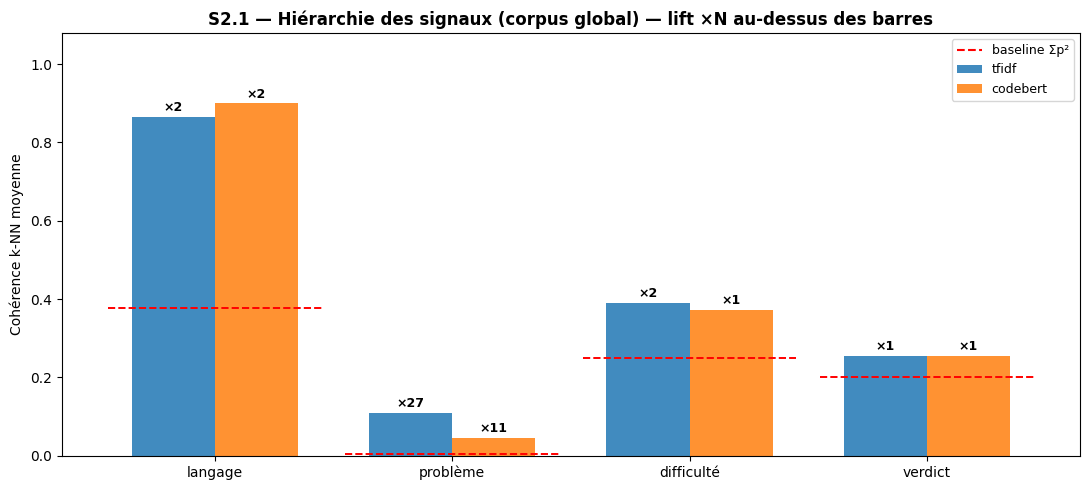

In [5]:
from sklearn.neighbors import NearestNeighbors

K = 10
TARGET_LABELS = ['language', 'problem_id', 'difficulty', 'status_code']
LABEL_NAMES   = {'language': 'langage', 'problem_id': 'problème',
                 'difficulty': 'difficulté', 'status_code': 'verdict'}

signal_rows = []
for m in METHODS:
    if m not in embeddings_all:
        continue
    emb, meta = embeddings_all[m], df_meta_all[m]
    print(f"k-NN — {m} (k={K}, cosine)...")
    nbrs = NearestNeighbors(n_neighbors=K + 1, metric='cosine', algorithm='brute', n_jobs=-1)
    nbrs.fit(emb)
    _, idx = nbrs.kneighbors(emb)   # une seule passe k-NN par méthode, réutilisée pour les 4 étiquettes

    for col in TARGET_LABELS:
        labels = meta[col].to_numpy()
        cons = float(np.mean([
            np.sum(labels[idx[i, 1:]] == labels[i]) / K for i in range(len(labels))
        ]))
        probs = meta[col].value_counts()['count'].to_numpy() / len(meta)
        base  = float(np.sum(probs ** 2))
        signal_rows.append({'method': m, 'label': col, 'consistency': cons,
                            'baseline': base, 'lift': cons / base})
        print(f"  {LABEL_NAMES[col]:12s} : cohérence {cons:.3f} | baseline {base:.3f} | lift ×{cons/base:.1f}")

df_signals = pl.DataFrame(signal_rows)

# --- Figure : hiérarchie des signaux — cohérence par étiquette, baseline en tirets ---
loaded = [m for m in METHODS if m in embeddings_all]
x, width = np.arange(len(TARGET_LABELS)), 0.35

fig, ax = plt.subplots(figsize=(11, 5))
for off, m in zip(np.linspace(-width/2, width/2, len(loaded)), loaded):
    sub  = {r['label']: r for r in signal_rows if r['method'] == m}
    vals = [sub[l]['consistency'] for l in TARGET_LABELS]
    bars = ax.bar(x + off, vals, width, label=m, alpha=0.85)
    for l, b in zip(TARGET_LABELS, bars):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.015,
                f"×{sub[l]['lift']:.0f}", ha='center', fontsize=9, fontweight='bold')

base_by_label = {r['label']: r['baseline'] for r in signal_rows}
for xi, l in zip(x, TARGET_LABELS):
    ax.hlines(base_by_label[l], xi - 0.45, xi + 0.45,
              color='red', linestyle='--', linewidth=1.4)
ax.plot([], [], color='red', linestyle='--', label='baseline Σp²')

ax.set_xticks(x)
ax.set_xticklabels([LABEL_NAMES[l] for l in TARGET_LABELS])
ax.set_ylabel('Cohérence k-NN moyenne')
ax.set_ylim(0, 1.08)
ax.set_title('S2.1 — Hiérarchie des signaux (corpus global) — lift ×N au-dessus des barres',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Fit UMAP — tfidf (9993 points)...


/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  tfidf : fait.
Fit UMAP — codebert (9993 points)...


/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  codebert : fait.


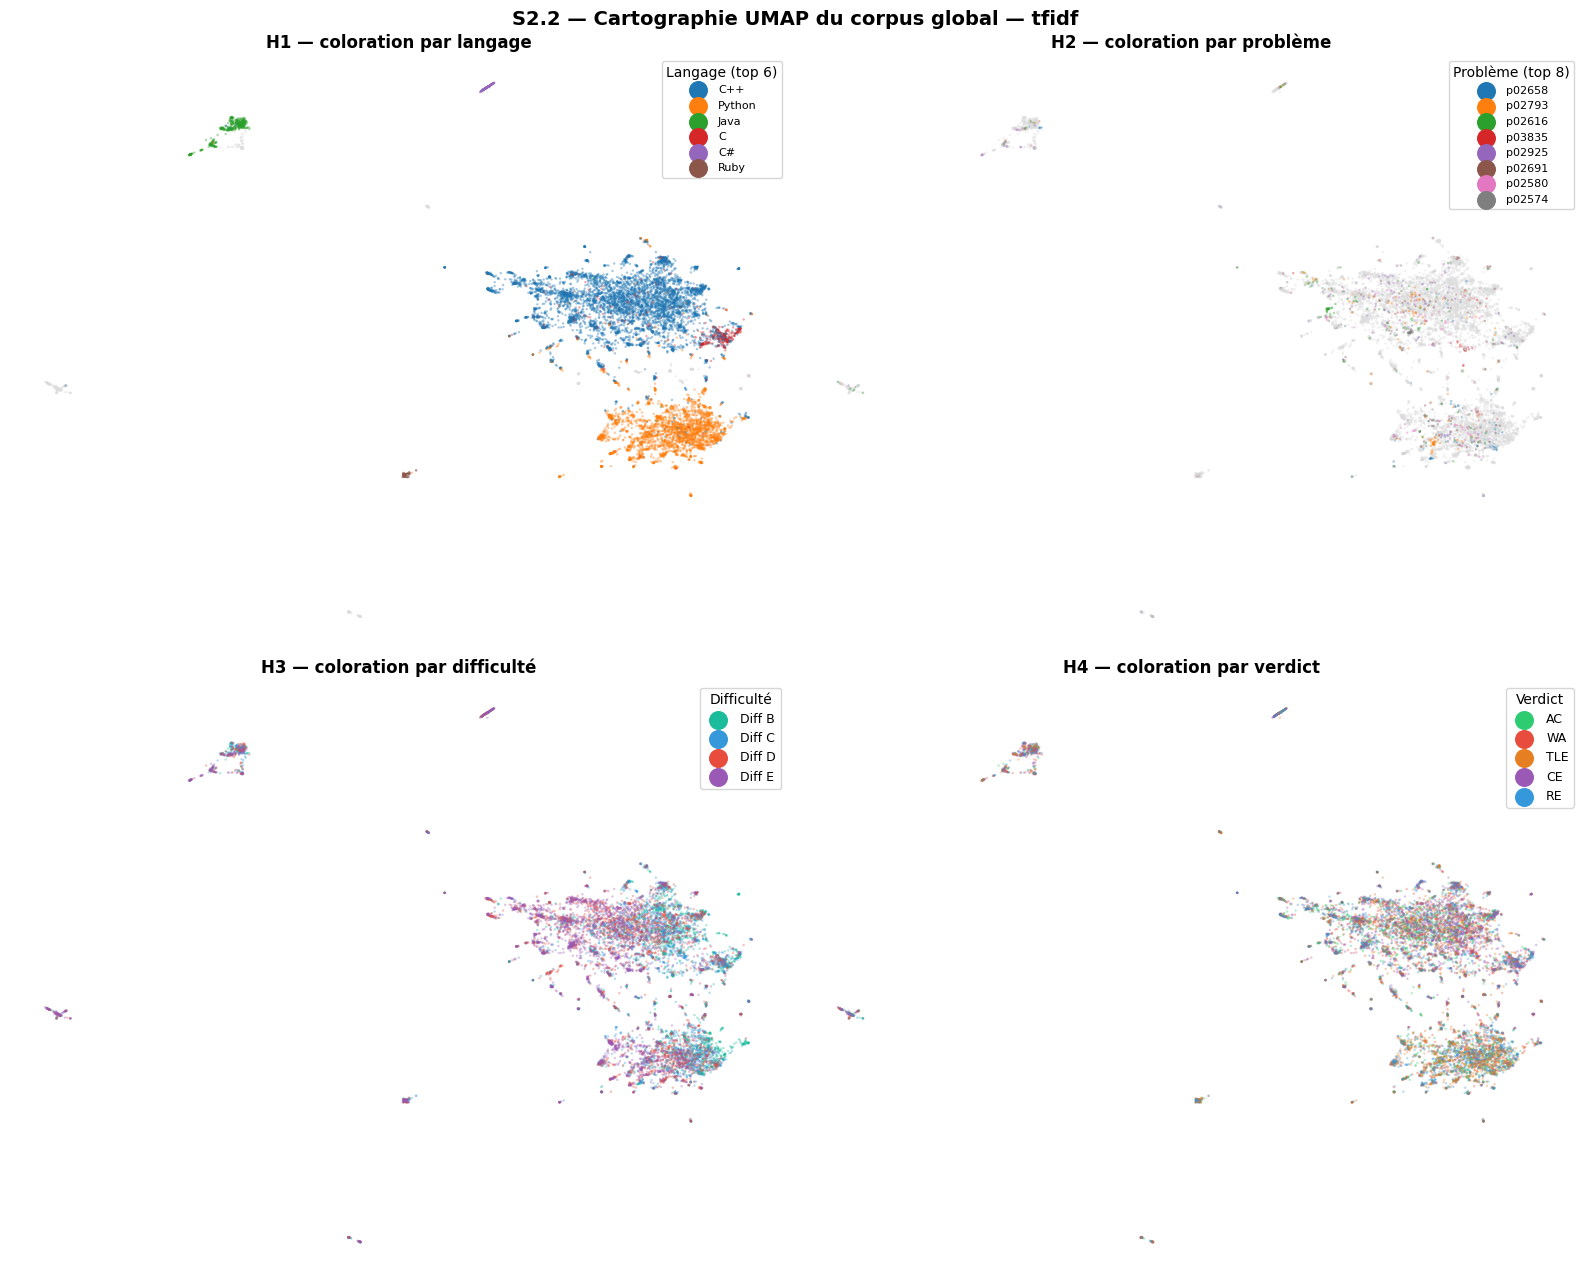

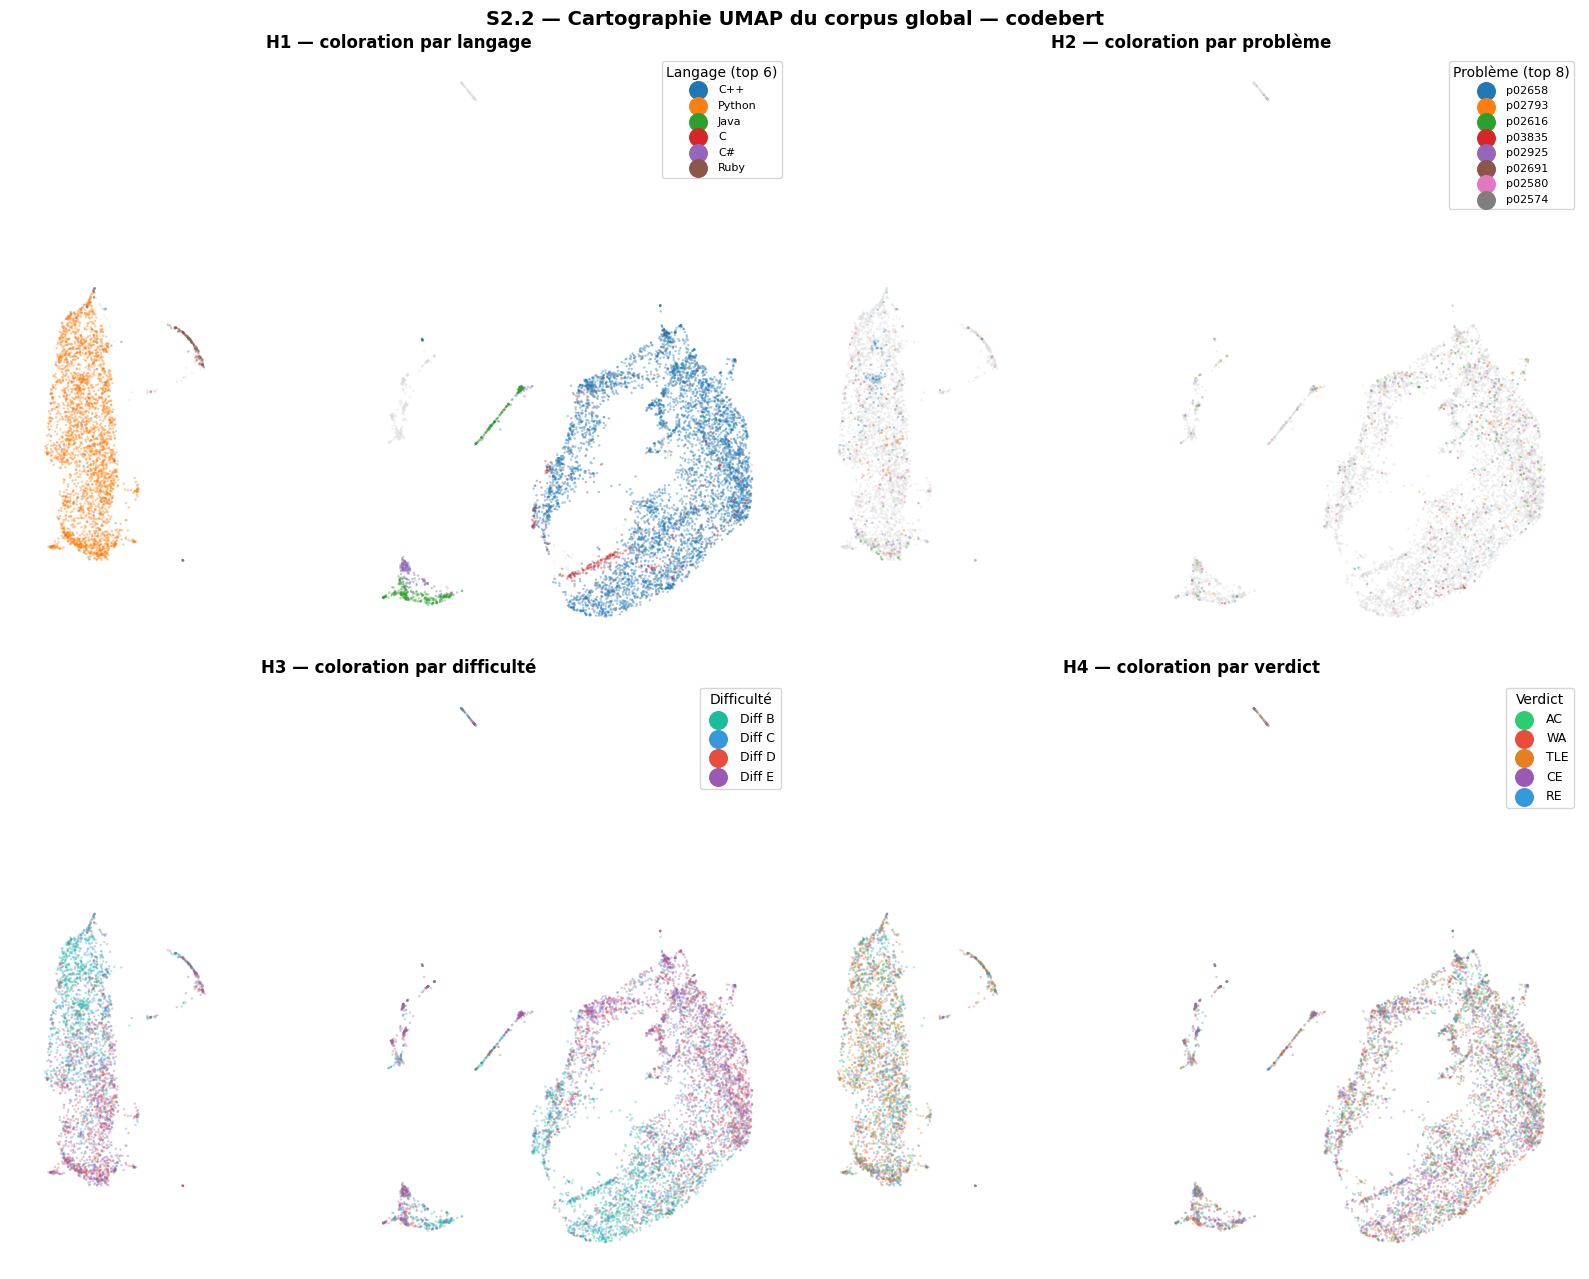

In [6]:
umap_2d_all = {}

try:
    import umap

    for m in METHODS:
        if m not in embeddings_all:
            continue
        print(f"Fit UMAP — {m} ({embeddings_all[m].shape[0]} points)...")
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                            random_state=42, metric='cosine')
        umap_2d_all[m] = reducer.fit_transform(embeddings_all[m])
        print(f"  {m} : fait.")

    palette = plt.cm.tab10.colors

    for m in [m for m in METHODS if m in umap_2d_all]:
        meta, proj = df_meta_all[m], umap_2d_all[m]
        fig, axes = plt.subplots(2, 2, figsize=(16, 13))

        # H1 — langage (top 6, reste en gris clair)
        top_langs  = meta['language'].value_counts().sort('count', descending=True).head(6)['language'].to_list()
        lang_color = {l: palette[i] for i, l in enumerate(top_langs)}
        ax = axes[0, 0]
        ax.scatter(proj[:, 0], proj[:, 1],
                   c=[lang_color.get(l, '#dddddd') for l in meta['language'].to_list()],
                   s=3, alpha=0.4, linewidths=0)
        for l in top_langs:
            ax.scatter([], [], c=[lang_color[l]], s=40, label=l)
        ax.legend(title='Langage (top 6)', fontsize=8, markerscale=2, framealpha=0.8)
        ax.set_title('H1 — coloration par langage', fontsize=12, fontweight='bold')
        ax.axis('off')

        # H2 — problème (top 8, reste en gris clair)
        top_pbs  = meta['problem_id'].value_counts().sort('count', descending=True).head(8)['problem_id'].to_list()
        pb_color = {p: palette[i] for i, p in enumerate(top_pbs)}
        ax = axes[0, 1]
        ax.scatter(proj[:, 0], proj[:, 1],
                   c=[pb_color.get(p, '#dddddd') for p in meta['problem_id'].to_list()],
                   s=3, alpha=0.4, linewidths=0)
        for p in top_pbs:
            ax.scatter([], [], c=[pb_color[p]], s=40, label=p)
        ax.legend(title='Problème (top 8)', fontsize=8, markerscale=2, framealpha=0.8)
        ax.set_title('H2 — coloration par problème', fontsize=12, fontweight='bold')
        ax.axis('off')

        # H3 — difficulté (artefact de H2 attendu : les clusters sont des problèmes)
        ax = axes[1, 0]
        ax.scatter(proj[:, 0], proj[:, 1],
                   c=[DIFF_COLORS.get(d, '#aaaaaa') for d in meta['difficulty'].to_list()],
                   s=3, alpha=0.35, linewidths=0)
        for d, c in DIFF_COLORS.items():
            ax.scatter([], [], c=c, s=40, label=f'Diff {d}')
        ax.legend(title='Difficulté', fontsize=9, markerscale=2, framealpha=0.8)
        ax.set_title('H3 — coloration par difficulté', fontsize=12, fontweight='bold')
        ax.axis('off')

        # H4 — verdict
        ax = axes[1, 1]
        ax.scatter(proj[:, 0], proj[:, 1],
                   c=[STATUS_COLORS.get(s, '#aaaaaa') for s in meta['status_code'].to_list()],
                   s=3, alpha=0.35, linewidths=0)
        for s, c in STATUS_COLORS.items():
            ax.scatter([], [], c=c, s=40, label=s)
        ax.legend(title='Verdict', fontsize=9, markerscale=2, framealpha=0.8)
        ax.set_title('H4 — coloration par verdict', fontsize=12, fontweight='bold')
        ax.axis('off')

        fig.suptitle(f'S2.2 — Cartographie UMAP du corpus global — {m}',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

except ImportError:
    print("UMAP non installé — pip install umap-learn")

### S2.3 — Mesure dédiée du verdict (H4) : distribution individuelle
#### S2.3 — Dedicated Verdict Measurement (H4): Per-Submission Distribution

Histogramme de la cohérence k-NN *verdict* par soumission, sur le corpus global. Lecture attendue : la masse de la distribution se situe près de la baseline — le verdict est invisible à l'échelle globale. Une queue droite (soumissions à cohérence ≥ 0,7) signalerait en revanche des poches locales d'homogénéité, que S2.4 localise.

---

Histogram of per-submission *verdict* k-NN consistency on the global corpus. Expected reading: the mass of the distribution sits near the baseline — the verdict is invisible at global scale. A right tail (submissions with consistency ≥ 0.7) would instead indicate local pockets of homogeneity, which S2.4 localizes.


k-NN — tfidf (k=10, cosine brute)...
  Cohérence moyenne : 0.255  |  baseline : 0.200  |  lift : ×1.27

k-NN — codebert (k=10, cosine brute)...
  Cohérence moyenne : 0.255  |  baseline : 0.200  |  lift : ×1.28


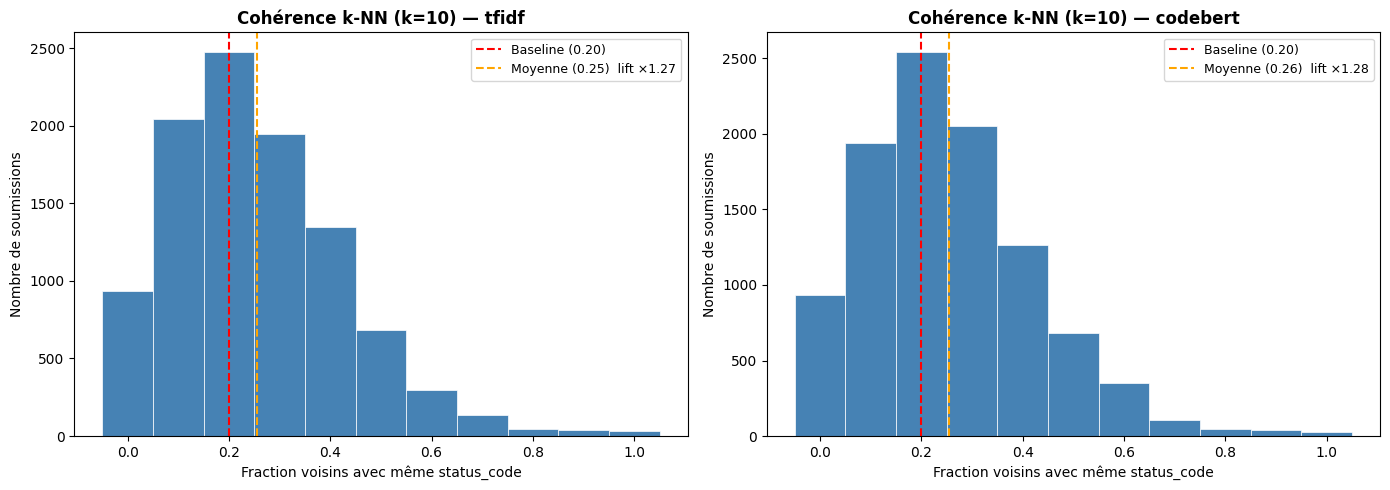

In [7]:
from sklearn.neighbors import NearestNeighbors

K = 10
knn_results = {}

for m in METHODS:
    if m not in embeddings_all:
        continue
    emb  = embeddings_all[m]
    meta = df_meta_all[m]

    print(f"\nk-NN — {m} (k={K}, cosine brute)...")
    nbrs = NearestNeighbors(n_neighbors=K + 1, metric='cosine', algorithm='brute', n_jobs=-1)
    nbrs.fit(emb)
    _, indices = nbrs.kneighbors(emb)

    statuses_arr = meta['status_code'].to_numpy()
    consistencies = [
        np.sum(statuses_arr[indices[i, 1:]] == statuses_arr[i]) / K
        for i in range(len(statuses_arr))
    ]

    df_meta_all[m] = meta.with_columns(pl.Series('knn_consistency', consistencies))

    mean_c = float(np.mean(consistencies))
    vc = meta['status_code'].value_counts()
    class_probs   = vc['count'].to_numpy() / len(meta)
    rand_baseline = float(np.sum(class_probs ** 2))

    knn_results[m] = {
        'consistencies': consistencies,
        'mean_c':        mean_c,
        'rand_baseline': rand_baseline,
        'lift':          mean_c / rand_baseline,
    }
    print(f"  Cohérence moyenne : {mean_c:.3f}  |  baseline : {rand_baseline:.3f}  |  lift : ×{mean_c / rand_baseline:.2f}")

# --- Figure : grille 2×2 (ou 1×N si N ≤ 2) ---
loaded = [m for m in METHODS if m in knn_results]
n = len(loaded)
ncols = min(n, 2)
nrows = (n + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
axes_flat = np.array(axes).flatten()
for ax in axes_flat[n:]:
    ax.set_visible(False)

for ax, m in zip(axes_flat, loaded):
    r = knn_results[m]
    ax.hist(r['consistencies'], bins=K + 1, range=(-0.05, 1.05),
            color='steelblue', edgecolor='white', linewidth=0.5)
    ax.axvline(r['rand_baseline'], color='red',    linestyle='--', linewidth=1.5,
               label=f"Baseline ({r['rand_baseline']:.2f})")
    ax.axvline(r['mean_c'],        color='orange', linestyle='--', linewidth=1.5,
               label=f"Moyenne ({r['mean_c']:.2f})  lift ×{r['lift']:.2f}")
    ax.set_xlabel('Fraction voisins avec même status_code')
    ax.set_ylabel('Nombre de soumissions')
    ax.set_title(f'Cohérence k-NN (k={K}) — {m}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### S2.4 — Localisation du signal verdict : cohérence par (difficulté × verdict)
#### S2.4 — Localizing the Verdict Signal: Consistency by (Difficulty × Verdict)

Cohérence k-NN *verdict* moyenne, ventilée par case (difficulté × verdict). Les cases nettement au-dessus de la baseline localisent où l'espace global « voit » déjà le verdict malgré l'absence de contrôle — typiquement les CE, dont la signature lexicale (code non compilable) est indépendante du problème.

---

Mean *verdict* k-NN consistency, broken down by (difficulty × verdict) cell. Cells clearly above the baseline localize where the global space already "sees" the verdict despite the absence of any control — typically CE, whose lexical signature (non-compilable code) is problem-independent.

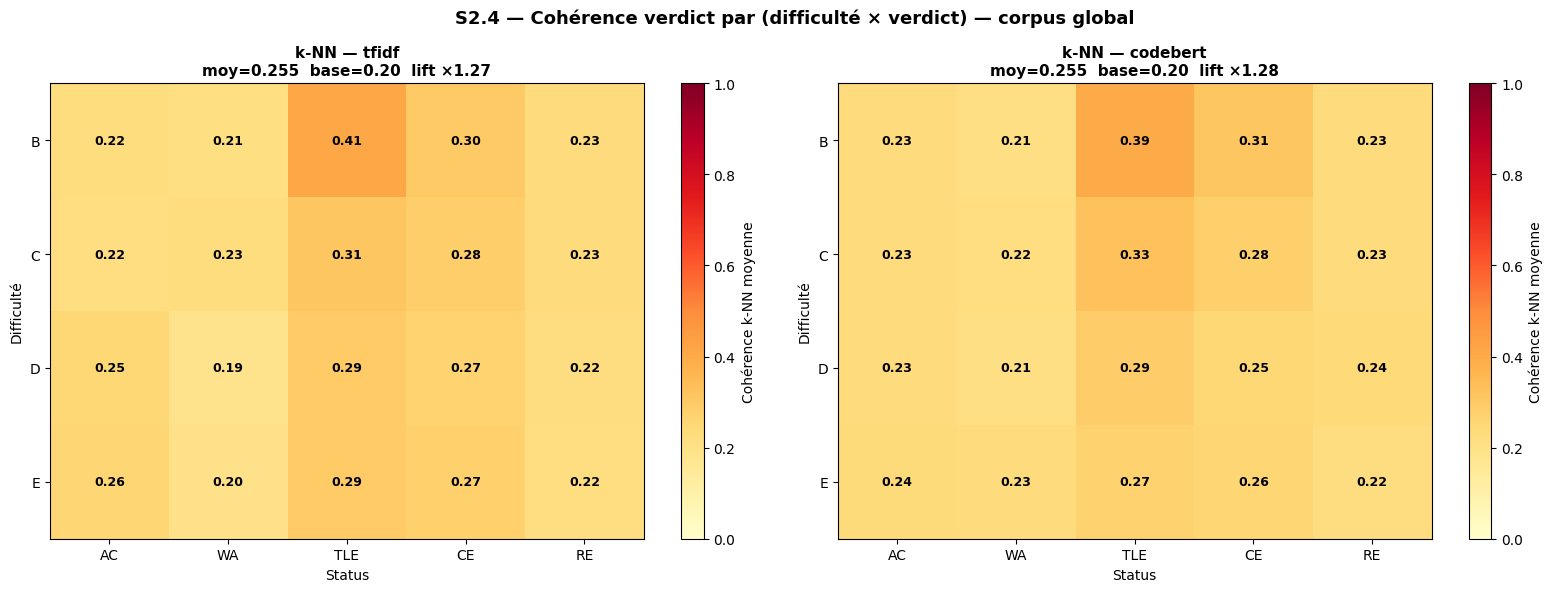

In [8]:
loaded = [m for m in METHODS if m in knn_results]
n = len(loaded)
ncols = min(n, 2)
nrows = (n + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6 * nrows))
axes_flat = np.array(axes).flatten()
for ax in axes_flat[n:]:
    ax.set_visible(False)

for ax, m in zip(axes_flat, loaded):
    meta = df_meta_all[m]
    r    = knn_results[m]

    pivot = (
        meta
        .group_by(['difficulty', 'status_code'])
        .agg(pl.col('knn_consistency').mean().alias('mean_c'))
    )

    matrix = np.full((len(DIFFS_ORDER), len(STATUSES_ORDER)), np.nan)
    for row in pivot.iter_rows(named=True):
        if row['difficulty'] in DIFFS_ORDER and row['status_code'] in STATUSES_ORDER:
            i = DIFFS_ORDER.index(row['difficulty'])
            j = STATUSES_ORDER.index(row['status_code'])
            matrix[i, j] = row['mean_c']

    im = ax.imshow(matrix, vmin=0, vmax=1, cmap='YlOrRd', aspect='auto')
    plt.colorbar(im, ax=ax, label='Cohérence k-NN moyenne')
    ax.set_xticks(range(len(STATUSES_ORDER))); ax.set_xticklabels(STATUSES_ORDER)
    ax.set_yticks(range(len(DIFFS_ORDER)));    ax.set_yticklabels(DIFFS_ORDER)
    ax.set_xlabel('Status'); ax.set_ylabel('Difficulté')
    ax.set_title(
        f'k-NN — {m}\n'
        f'moy={r["mean_c"]:.3f}  base={r["rand_baseline"]:.2f}  lift ×{r["lift"]:.2f}',
        fontsize=11, fontweight='bold'
    )

    for i in range(len(DIFFS_ORDER)):
        for j in range(len(STATUSES_ORDER)):
            if not np.isnan(matrix[i, j]):
                txt_c = 'white' if matrix[i, j] > 0.6 else 'black'
                ax.text(j, i, f'{matrix[i, j]:.2f}',
                        ha='center', va='center', fontsize=9,
                        color=txt_c, fontweight='bold')

fig.suptitle('S2.4 — Cohérence verdict par (difficulté × verdict) — corpus global',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## S3 — Contrôle du facteur langage : corpus C++
### S3 — Controlling for Language: the C++-only Corpus

S2 a établi que le langage domine la géométrie de l'espace. On neutralise ce facteur en restreignant le corpus au langage majoritaire — **C++** (C++14/17/20, ~54 % du volume) — tous problèmes confondus.

**Question** : à syntaxe constante, le verdict émerge-t-il ? **Attendu** : un gain modeste seulement — le facteur problème (H2) structure encore l'espace. La comparaison des heatmaps S3 contre S2.4 quantifie précisément ce que le contrôle du langage apporte, et ce que le facteur problème continue de masquer — d'où S4.

---

S2 established that language dominates the geometry of the space. We neutralize this factor by restricting the corpus to the majority language — **C++** (C++14/17/20, ~54% of the volume) — all problems pooled.

**Question**: with syntax held constant, does the verdict emerge? **Expected**: only a modest gain — the problem factor (H2) still structures the space. Comparing the S3 heatmaps against S2.4 quantifies exactly what controlling for language buys, and what the problem factor keeps masking — hence S4.

In [9]:
METHODS_CPP = ["tfidf_cpp", "codebert_cpp"]

embeddings_cpp = {}
df_meta_cpp    = {}

for m in METHODS_CPP:
    emb_path  = EMBEDDINGS_DIR / f"embeddings_{m}.npy"
    meta_path = EMBEDDINGS_DIR / f"metadata_{m}.csv"
    if not emb_path.exists():
        print(f"[MANQUANT] {m} — lancer : python src/embedding.py {m.replace('_cpp','')} cpu \"C++\"")
        continue
    embeddings_cpp[m] = np.load(emb_path)
    df_meta_cpp[m]    = pl.read_csv(meta_path)
    lang_dist = df_meta_cpp[m]['language'].value_counts().sort('count', descending=True).head(3)
    print(f"{m:15s} : {embeddings_cpp[m].shape}  |  {df_meta_cpp[m].height:,} soumissions")
    print(f"  Langages : {lang_dist['language'].to_list()}")

print(f"\nMéthodes C++ chargées : {list(embeddings_cpp.keys())}")

tfidf_cpp       : (9980, 10000)  |  9,980 soumissions
  Langages : ['C++']
codebert_cpp    : (9980, 768)  |  9,980 soumissions
  Langages : ['C++']

Méthodes C++ chargées : ['tfidf_cpp', 'codebert_cpp']


Fit UMAP — tfidf_cpp (9980 points)...


/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  tfidf_cpp : fait.
Fit UMAP — codebert_cpp (9980 points)...


/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  codebert_cpp : fait.


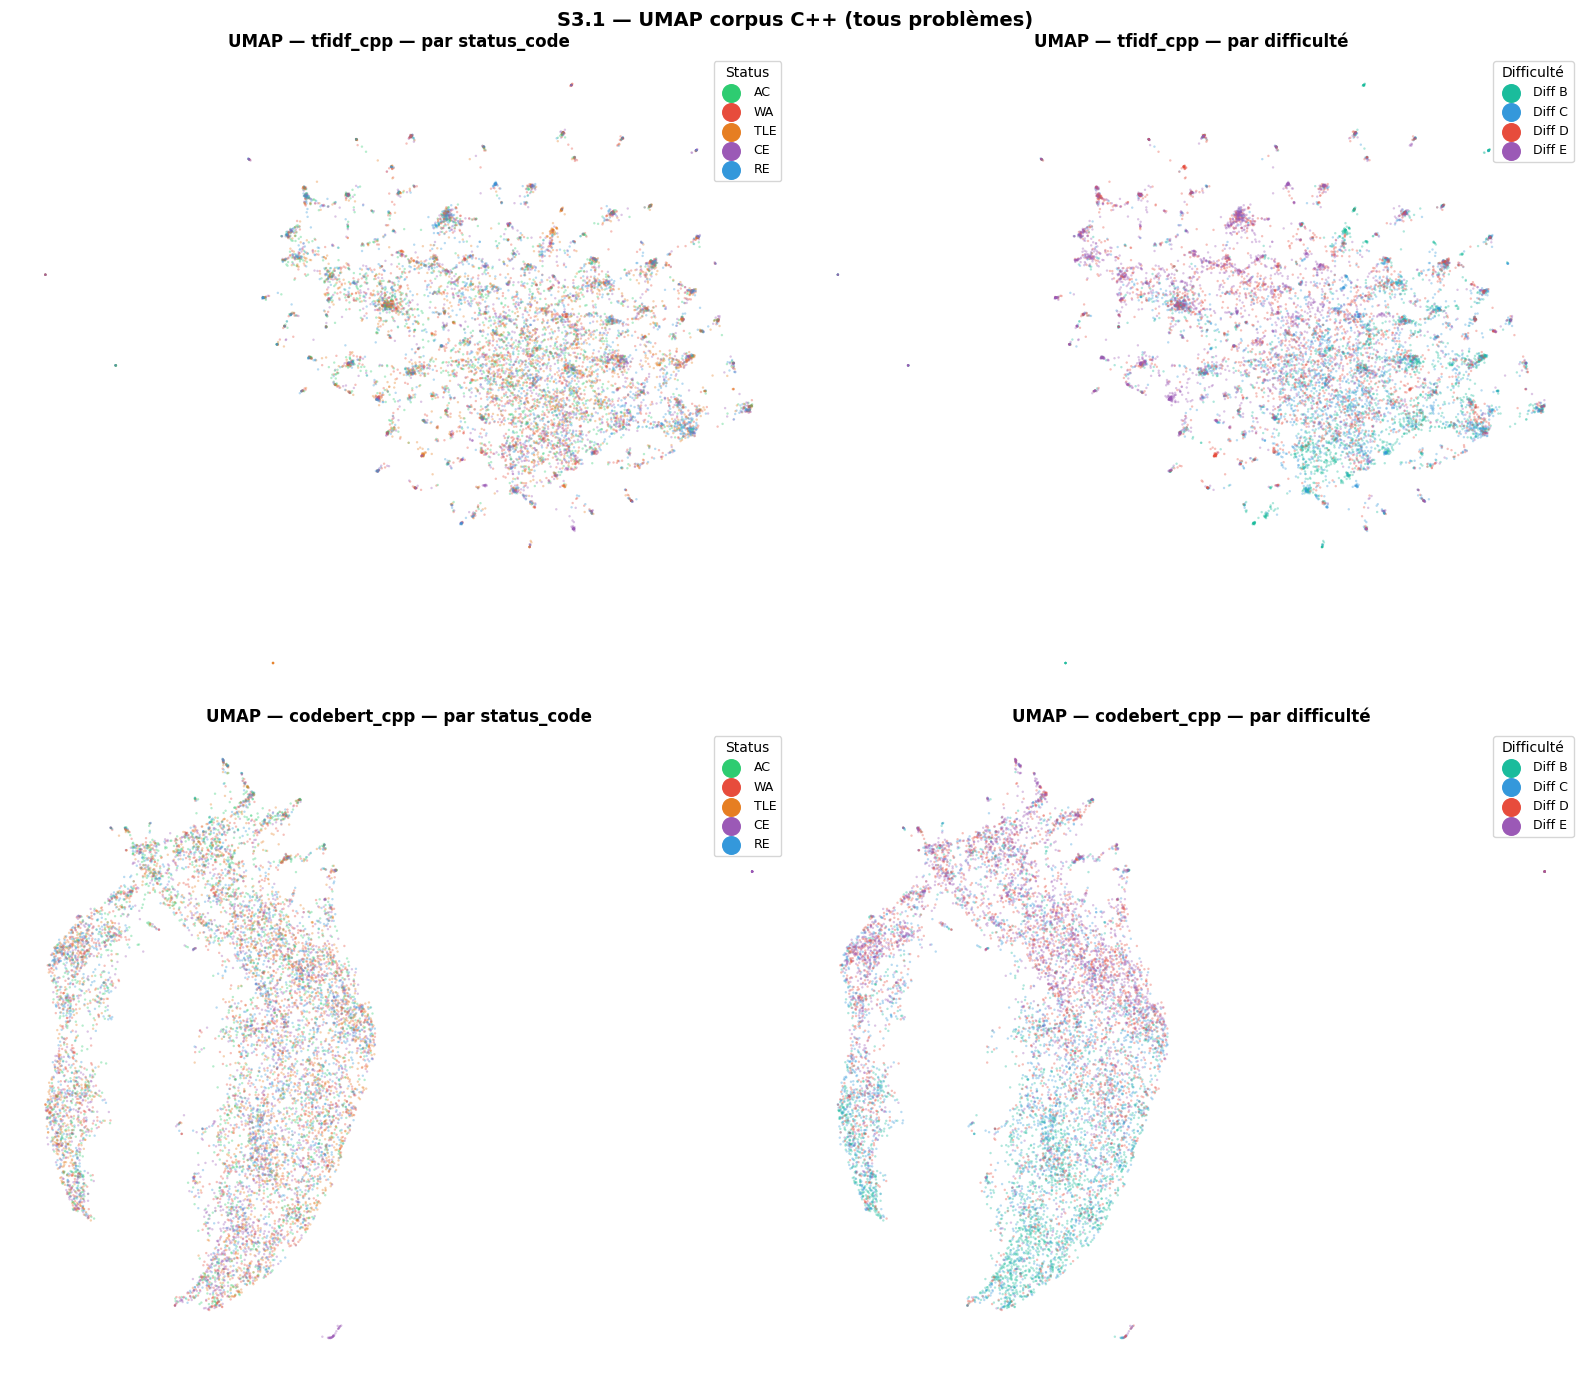

In [10]:
umap_2d_cpp = {}

try:
    import umap

    for m in METHODS_CPP:
        if m not in embeddings_cpp:
            continue
        print(f"Fit UMAP — {m} ({embeddings_cpp[m].shape[0]} points)...")
        reducer = umap.UMAP(
            n_neighbors=15, min_dist=0.1, n_components=2,
            random_state=42, metric='cosine',
        )
        umap_2d_cpp[m] = reducer.fit_transform(embeddings_cpp[m])
        print(f"  {m} : fait.")

    loaded_cpp = [m for m in METHODS_CPP if m in umap_2d_cpp]
    n_rows = len(loaded_cpp)

    fig, axes = plt.subplots(n_rows, 2, figsize=(16, 7 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    for row_i, m in enumerate(loaded_cpp):
        meta = df_meta_cpp[m]
        proj = umap_2d_cpp[m]

        ax = axes[row_i, 0]
        colors_status = [STATUS_COLORS.get(s, '#aaaaaa') for s in meta['status_code'].to_list()]
        ax.scatter(proj[:, 0], proj[:, 1], c=colors_status, s=3, alpha=0.35, linewidths=0)
        for s, c in STATUS_COLORS.items():
            ax.scatter([], [], c=c, s=40, label=s)
        ax.legend(title='Status', fontsize=9, markerscale=2, framealpha=0.8)
        ax.set_title(f'UMAP — {m} — par status_code', fontsize=12, fontweight='bold')
        ax.axis('off')

        ax = axes[row_i, 1]
        colors_diff = [DIFF_COLORS.get(d, '#aaaaaa') for d in meta['difficulty'].to_list()]
        ax.scatter(proj[:, 0], proj[:, 1], c=colors_diff, s=3, alpha=0.35, linewidths=0)
        for d, c in DIFF_COLORS.items():
            ax.scatter([], [], c=c, s=40, label=f'Diff {d}')
        ax.legend(title='Difficulté', fontsize=9, markerscale=2, framealpha=0.8)
        ax.set_title(f'UMAP — {m} — par difficulté', fontsize=12, fontweight='bold')
        ax.axis('off')

    fig.suptitle('S3.1 — UMAP corpus C++ (tous problèmes)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

except ImportError:
    print("UMAP non installé — pip install umap-learn")


k-NN — tfidf_cpp (k=10, cosine brute)...
  Cohérence moyenne : 0.248  |  baseline : 0.200  |  lift : ×1.24

k-NN — codebert_cpp (k=10, cosine brute)...
  Cohérence moyenne : 0.233  |  baseline : 0.200  |  lift : ×1.17


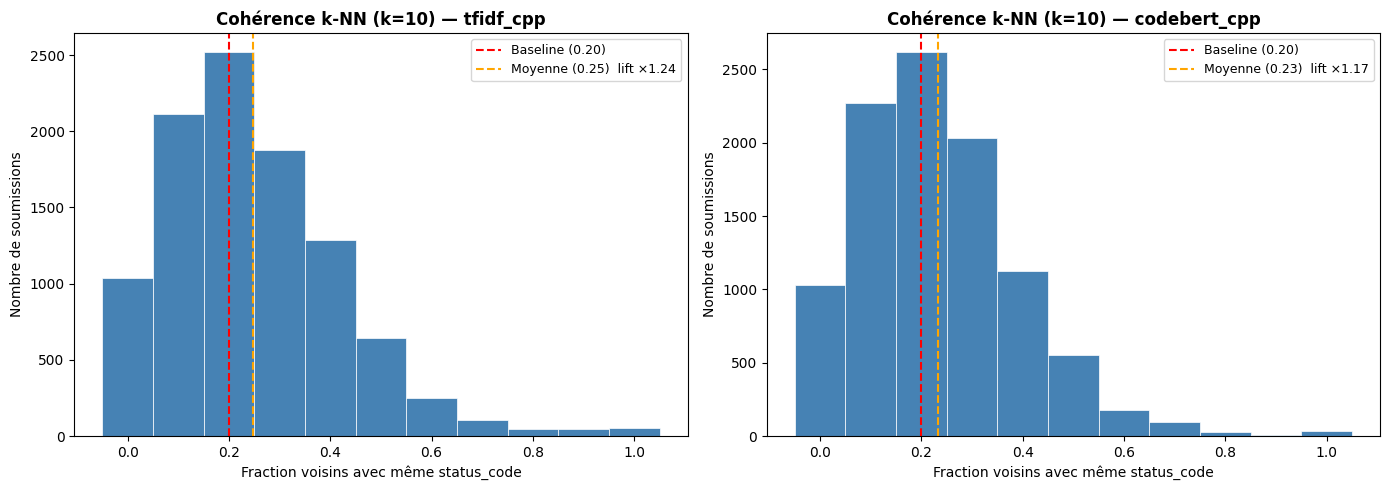

In [11]:
from sklearn.neighbors import NearestNeighbors

K = 10
knn_cpp = {}

for m in METHODS_CPP:
    if m not in embeddings_cpp:
        continue
    emb  = embeddings_cpp[m]
    meta = df_meta_cpp[m]

    print(f"\nk-NN — {m} (k={K}, cosine brute)...")
    nbrs = NearestNeighbors(n_neighbors=K + 1, metric='cosine', algorithm='brute', n_jobs=-1)
    nbrs.fit(emb)
    _, indices = nbrs.kneighbors(emb)

    statuses_arr  = meta['status_code'].to_numpy()
    consistencies = [
        np.sum(statuses_arr[indices[i, 1:]] == statuses_arr[i]) / K
        for i in range(len(statuses_arr))
    ]

    df_meta_cpp[m] = meta.with_columns(pl.Series('knn_consistency', consistencies))

    mean_c = float(np.mean(consistencies))
    vc = meta['status_code'].value_counts()
    class_probs   = vc['count'].to_numpy() / len(meta)
    rand_baseline = float(np.sum(class_probs ** 2))

    knn_cpp[m] = {
        'consistencies': consistencies,
        'mean_c':        mean_c,
        'rand_baseline': rand_baseline,
        'lift':          mean_c / rand_baseline,
    }
    print(f"  Cohérence moyenne : {mean_c:.3f}  |  baseline : {rand_baseline:.3f}  |  lift : ×{mean_c / rand_baseline:.2f}")

loaded_cpp = [m for m in METHODS_CPP if m in knn_cpp]
fig, axes = plt.subplots(1, len(loaded_cpp), figsize=(7 * len(loaded_cpp), 5))
if len(loaded_cpp) == 1:
    axes = [axes]

for ax, m in zip(axes, loaded_cpp):
    r = knn_cpp[m]
    ax.hist(r['consistencies'], bins=K + 1, range=(-0.05, 1.05),
            color='steelblue', edgecolor='white', linewidth=0.5)
    ax.axvline(r['rand_baseline'], color='red',    linestyle='--', linewidth=1.5,
               label=f"Baseline ({r['rand_baseline']:.2f})")
    ax.axvline(r['mean_c'],        color='orange', linestyle='--', linewidth=1.5,
               label=f"Moyenne ({r['mean_c']:.2f})  lift ×{r['lift']:.2f}")
    ax.set_xlabel('Fraction voisins avec même status_code')
    ax.set_ylabel('Nombre de soumissions')
    ax.set_title(f'Cohérence k-NN (k={K}) — {m}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

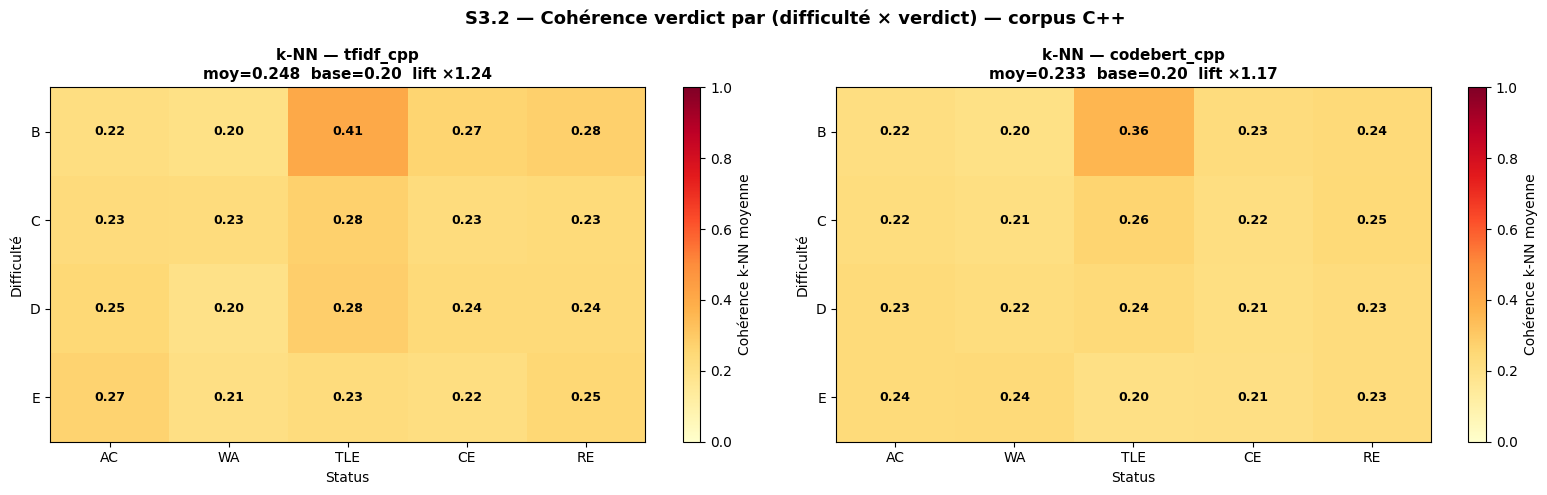

In [12]:
loaded_cpp = [m for m in METHODS_CPP if m in knn_cpp]
fig, axes = plt.subplots(1, len(loaded_cpp), figsize=(8 * len(loaded_cpp), 5))
if len(loaded_cpp) == 1:
    axes = [axes]

for ax, m in zip(axes, loaded_cpp):
    meta = df_meta_cpp[m]
    r    = knn_cpp[m]

    pivot = (
        meta
        .group_by(['difficulty', 'status_code'])
        .agg(pl.col('knn_consistency').mean().alias('mean_c'))
    )

    matrix = np.full((len(DIFFS_ORDER), len(STATUSES_ORDER)), np.nan)
    for row in pivot.iter_rows(named=True):
        if row['difficulty'] in DIFFS_ORDER and row['status_code'] in STATUSES_ORDER:
            i = DIFFS_ORDER.index(row['difficulty'])
            j = STATUSES_ORDER.index(row['status_code'])
            matrix[i, j] = row['mean_c']

    im = ax.imshow(matrix, vmin=0, vmax=1, cmap='YlOrRd', aspect='auto')
    plt.colorbar(im, ax=ax, label='Cohérence k-NN moyenne')
    ax.set_xticks(range(len(STATUSES_ORDER))); ax.set_xticklabels(STATUSES_ORDER)
    ax.set_yticks(range(len(DIFFS_ORDER)));    ax.set_yticklabels(DIFFS_ORDER)
    ax.set_xlabel('Status'); ax.set_ylabel('Difficulté')
    ax.set_title(
        f'k-NN — {m}\n'
        f'moy={r["mean_c"]:.3f}  base={r["rand_baseline"]:.2f}  lift ×{r["lift"]:.2f}',
        fontsize=11, fontweight='bold'
    )

    for i in range(len(DIFFS_ORDER)):
        for j in range(len(STATUSES_ORDER)):
            if not np.isnan(matrix[i, j]):
                txt_c = 'white' if matrix[i, j] > 0.6 else 'black'
                ax.text(j, i, f'{matrix[i, j]:.2f}',
                        ha='center', va='center', fontsize=9,
                        color=txt_c, fontweight='bold')

fig.suptitle('S3.2 — Cohérence verdict par (difficulté × verdict) — corpus C++',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## S4 — Contrôle du facteur problème : un problème, tous langages
### S4 — Controlling for Problem: One Problem, All Languages

Corpus : l'intégralité des soumissions échantillonnées d'un **problème unique** (`PROBLEM_ID`), tous langages confondus. Tous les codes visent la même spécification — le facteur problème est éliminé. Deux questions distinctes :

1. **S4.2 — Test sémantique inter-langages.** TF-IDF cloisonne par langage *par construction* (vocabulaires disjoints) : sa cohérence k-NN « langage » doit être ≈ 1. Si CodeBERT crée des ponts inter-langages — voisins C++ ↔ Python pour un même problème — et que **l'accord de verdict sur ces ponts** dépasse la baseline, c'est le premier indice direct que l'espace capture la logique au-delà de la syntaxe.
2. **S4.3 — Verdict à problème fixé.** Cohérence k-NN verdict dans ce corpus : tous les TLE ont raté *la même* contrainte algorithmique — condition la plus favorable avant le contrôle complet de S5.

**Choisir et générer le corpus :**
```bash
python src/embedding.py list D                  # top 30 problèmes D par volume
python src/embedding.py tfidf cpu "" p02616
python src/embedding.py codebert mps "" p02616
```

---

Corpus: every sampled submission of a **single problem** (`PROBLEM_ID`), all languages pooled. All codes target the same specification — the problem factor is eliminated. Two distinct questions:

1. **S4.2 — Cross-language semantic test.** TF-IDF partitions by language *by construction* (disjoint vocabularies): its "language" k-NN consistency must be ≈ 1. If CodeBERT builds cross-language bridges — C++ ↔ Python neighbors for the same problem — and **verdict agreement across those bridges** beats the baseline, this is the first direct evidence that the space captures logic beyond syntax.
2. **S4.3 — Verdict with the problem fixed.** Verdict k-NN consistency in this corpus: every TLE failed *the same* algorithmic constraint — the most favorable condition before S5's full control.

In [13]:
PROBLEM_ID = "p02616"  # changer ici selon le problème choisi
METHODS_PB = [f"tfidf_{PROBLEM_ID}", f"codebert_{PROBLEM_ID}"]

embeddings_pb = {}
df_meta_pb    = {}

for m in METHODS_PB:
    emb_path  = EMBEDDINGS_DIR / f"embeddings_{m}.npy"
    meta_path = EMBEDDINGS_DIR / f"metadata_{m}.csv"
    if not emb_path.exists():
        base = m.split("_")[0]
        print(f"[MANQUANT] {m} — lancer : python src/embedding.py {base} cpu \"\" {PROBLEM_ID}")
        continue
    embeddings_pb[m] = np.load(emb_path)
    df_meta_pb[m]    = pl.read_csv(meta_path)
    print(f"{m} : {embeddings_pb[m].shape}  |  {df_meta_pb[m].height:,} soumissions")
    print(f"  Status : {df_meta_pb[m]['status_code'].value_counts().sort('count', descending=True).to_dicts()}")

print(f"\nMéthodes chargées : {list(embeddings_pb.keys())}")

tfidf_p02616 : (2389, 10000)  |  2,389 soumissions
  Status : [{'status_code': 'WA', 'count': 500}, {'status_code': 'AC', 'count': 500}, {'status_code': 'RE', 'count': 500}, {'status_code': 'CE', 'count': 488}, {'status_code': 'TLE', 'count': 401}]
codebert_p02616 : (2389, 768)  |  2,389 soumissions
  Status : [{'status_code': 'RE', 'count': 500}, {'status_code': 'AC', 'count': 500}, {'status_code': 'WA', 'count': 500}, {'status_code': 'CE', 'count': 488}, {'status_code': 'TLE', 'count': 401}]

Méthodes chargées : ['tfidf_p02616', 'codebert_p02616']


Fit UMAP — tfidf_p02616...


/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  fait.
Fit UMAP — codebert_p02616...


/opt/homebrew/Caskroom/miniconda/base/envs/codenet/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  fait.


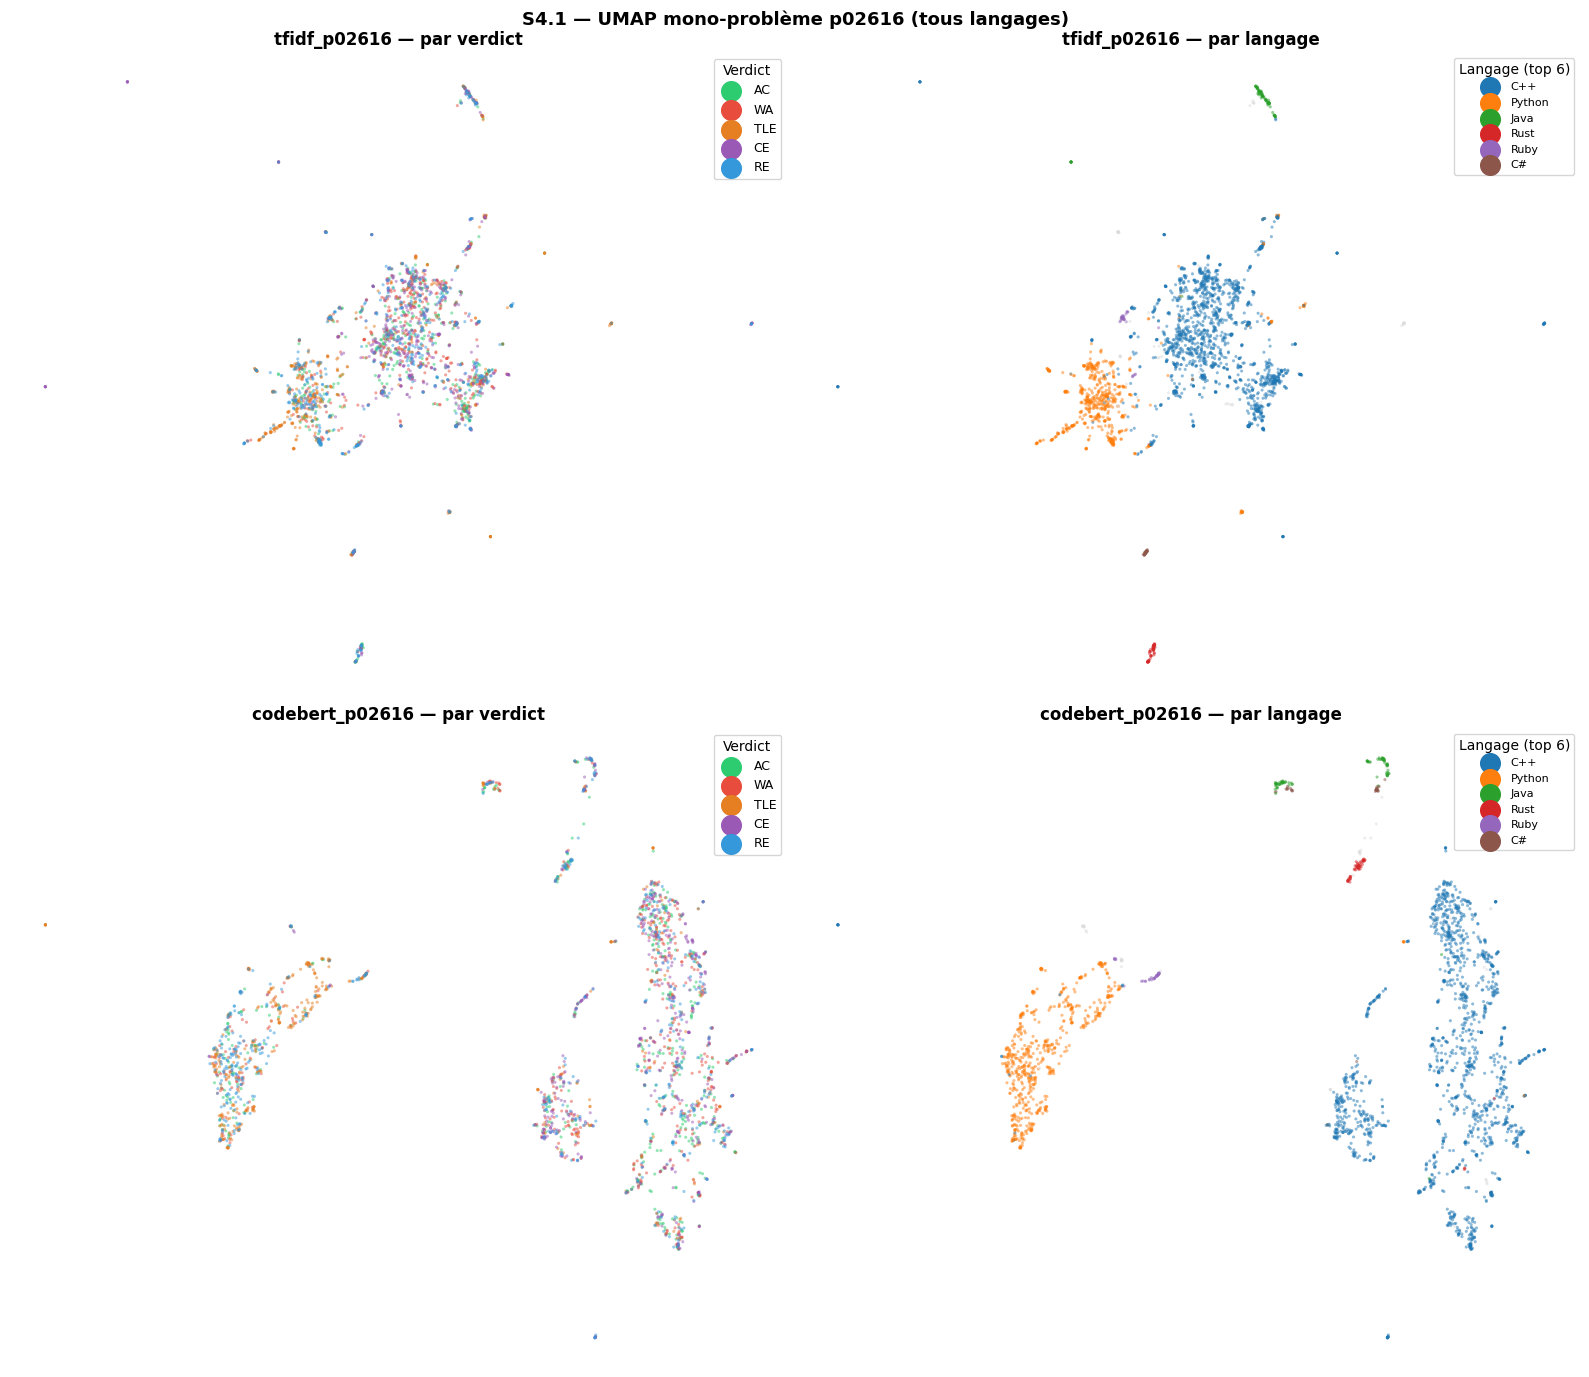

In [14]:
umap_2d_pb = {}

try:
    import umap

    for m in METHODS_PB:
        if m not in embeddings_pb:
            continue
        print(f"Fit UMAP — {m}...")
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                            random_state=42, metric='cosine')
        umap_2d_pb[m] = reducer.fit_transform(embeddings_pb[m])
        print("  fait.")

    palette   = plt.cm.tab10.colors
    loaded_pb = [m for m in METHODS_PB if m in umap_2d_pb]
    fig, axes = plt.subplots(len(loaded_pb), 2, figsize=(16, 7 * len(loaded_pb)))
    if len(loaded_pb) == 1:
        axes = axes[np.newaxis, :]

    for row_i, m in enumerate(loaded_pb):
        meta, proj = df_meta_pb[m], umap_2d_pb[m]

        # Colonne 0 — verdict
        ax = axes[row_i, 0]
        ax.scatter(proj[:, 0], proj[:, 1],
                   c=[STATUS_COLORS.get(s, '#aaaaaa') for s in meta['status_code'].to_list()],
                   s=5, alpha=0.5, linewidths=0)
        for s, c in STATUS_COLORS.items():
            ax.scatter([], [], c=c, s=50, label=s)
        ax.legend(title='Verdict', fontsize=9, markerscale=2, framealpha=0.8)
        ax.set_title(f'{m} — par verdict', fontsize=12, fontweight='bold')
        ax.axis('off')

        # Colonne 1 — langage (top 6, reste en gris) : cloisonnement vs ponts inter-langages
        top_langs  = meta['language'].value_counts().sort('count', descending=True).head(6)['language'].to_list()
        lang_color = {l: palette[i] for i, l in enumerate(top_langs)}
        ax = axes[row_i, 1]
        ax.scatter(proj[:, 0], proj[:, 1],
                   c=[lang_color.get(l, '#dddddd') for l in meta['language'].to_list()],
                   s=5, alpha=0.5, linewidths=0)
        for l in top_langs:
            ax.scatter([], [], c=[lang_color[l]], s=50, label=l)
        ax.legend(title='Langage (top 6)', fontsize=8, markerscale=2, framealpha=0.8)
        ax.set_title(f'{m} — par langage', fontsize=12, fontweight='bold')
        ax.axis('off')

    fig.suptitle(f'S4.1 — UMAP mono-problème {PROBLEM_ID} (tous langages)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

except ImportError:
    print("UMAP non installé — pip install umap-learn")

tfidf_p02616
  cloisonnement langage       : 0.934  (baseline 0.466 — 1.0 = aucun pont)
  paires de voisins inter-lang: 6.6%
  accord verdict sur les ponts: 0.164  (baseline verdict 0.201)

codebert_p02616
  cloisonnement langage       : 0.956  (baseline 0.466 — 1.0 = aucun pont)
  paires de voisins inter-lang: 4.4%
  accord verdict sur les ponts: 0.222  (baseline verdict 0.201)



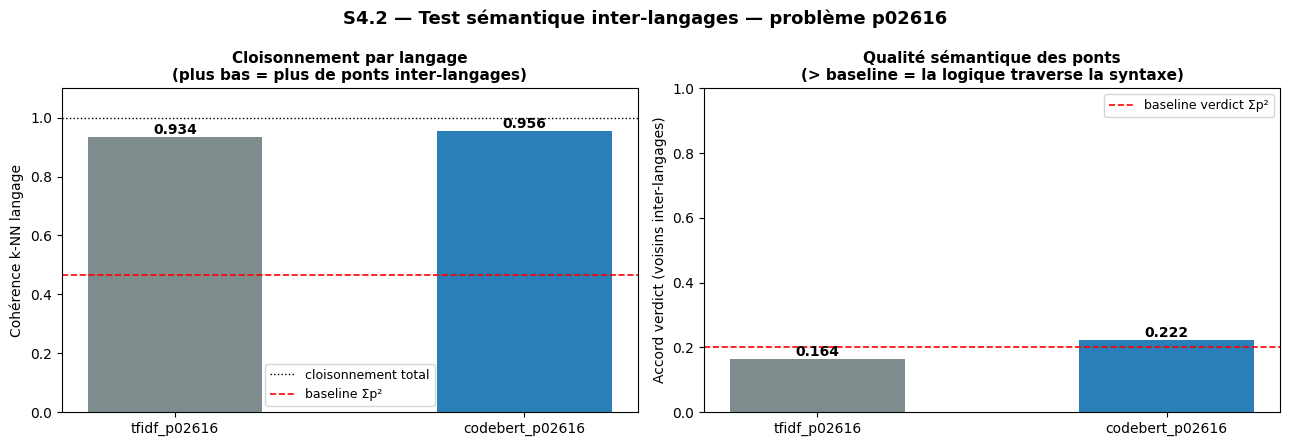

In [15]:
# S4.2 — Test sémantique inter-langages : TF-IDF cloisonne, CodeBERT construit-il des ponts ?
from sklearn.neighbors import NearestNeighbors

K = 10
semantic_results = {}

for m in METHODS_PB:
    if m not in embeddings_pb:
        continue
    emb, meta = embeddings_pb[m], df_meta_pb[m]
    langs    = meta['language'].to_numpy()
    statuses = meta['status_code'].to_numpy()

    nbrs = NearestNeighbors(n_neighbors=K + 1, metric='cosine', algorithm='brute', n_jobs=-1)
    nbrs.fit(emb)
    _, idx = nbrs.kneighbors(emb)

    # (1) Cloisonnement par langage : cohérence k-NN 'language' (1.0 = aucun pont)
    lang_cons = float(np.mean([
        np.sum(langs[idx[i, 1:]] == langs[i]) / K for i in range(len(langs))
    ]))
    lang_probs = meta['language'].value_counts()['count'].to_numpy() / len(meta)
    lang_base  = float(np.sum(lang_probs ** 2))

    # (2) Sur les ponts inter-langages : accord de verdict (le test sémantique)
    cross_match, cross_total = 0, 0
    for i in range(len(langs)):
        for j in idx[i, 1:]:
            if langs[j] != langs[i]:
                cross_total += 1
                if statuses[j] == statuses[i]:
                    cross_match += 1
    status_probs = meta['status_code'].value_counts()['count'].to_numpy() / len(meta)
    status_base  = float(np.sum(status_probs ** 2))
    cross_frac   = cross_total / (len(langs) * K)
    cross_status = cross_match / cross_total if cross_total else float('nan')

    semantic_results[m] = {'lang_cons': lang_cons, 'lang_base': lang_base,
                           'cross_frac': cross_frac, 'cross_status': cross_status,
                           'status_base': status_base}

    print(f"{m}")
    print(f"  cloisonnement langage       : {lang_cons:.3f}  (baseline {lang_base:.3f} — 1.0 = aucun pont)")
    print(f"  paires de voisins inter-lang: {cross_frac:.1%}")
    if cross_total:
        print(f"  accord verdict sur les ponts: {cross_status:.3f}  (baseline verdict {status_base:.3f})")
    print()

# --- Figure : cloisonnement (gauche) et qualité des ponts (droite) ---
loaded_pb = [m for m in METHODS_PB if m in semantic_results]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

vals = [semantic_results[m]['lang_cons'] for m in loaded_pb]
bars = ax1.bar(loaded_pb, vals, color=['#7f8c8d', '#2980b9'][:len(loaded_pb)], width=0.5)
ax1.axhline(1.0, color='black', linestyle=':', linewidth=1, label='cloisonnement total')
ax1.axhline(semantic_results[loaded_pb[0]]['lang_base'], color='red', linestyle='--',
            linewidth=1.2, label='baseline Σp²')
for b, v in zip(bars, vals):
    ax1.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
ax1.set_ylim(0, 1.1)
ax1.set_ylabel('Cohérence k-NN langage')
ax1.set_title('Cloisonnement par langage\n(plus bas = plus de ponts inter-langages)', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)

vals = [semantic_results[m]['cross_status'] for m in loaded_pb]
bars = ax2.bar(loaded_pb, vals, color=['#7f8c8d', '#2980b9'][:len(loaded_pb)], width=0.5)
ax2.axhline(semantic_results[loaded_pb[0]]['status_base'], color='red', linestyle='--',
            linewidth=1.2, label='baseline verdict Σp²')
for b, v in zip(bars, vals):
    if not np.isnan(v):
        ax2.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
ax2.set_ylim(0, 1.0)
ax2.set_ylabel('Accord verdict (voisins inter-langages)')
ax2.set_title('Qualité sémantique des ponts\n(> baseline = la logique traverse la syntaxe)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle(f'S4.2 — Test sémantique inter-langages — problème {PROBLEM_ID}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


k-NN — tfidf_p02616 (k=10)...
  Cohérence : 0.303  |  baseline : 0.201  |  lift ×1.50

k-NN — codebert_p02616 (k=10)...
  Cohérence : 0.302  |  baseline : 0.201  |  lift ×1.50


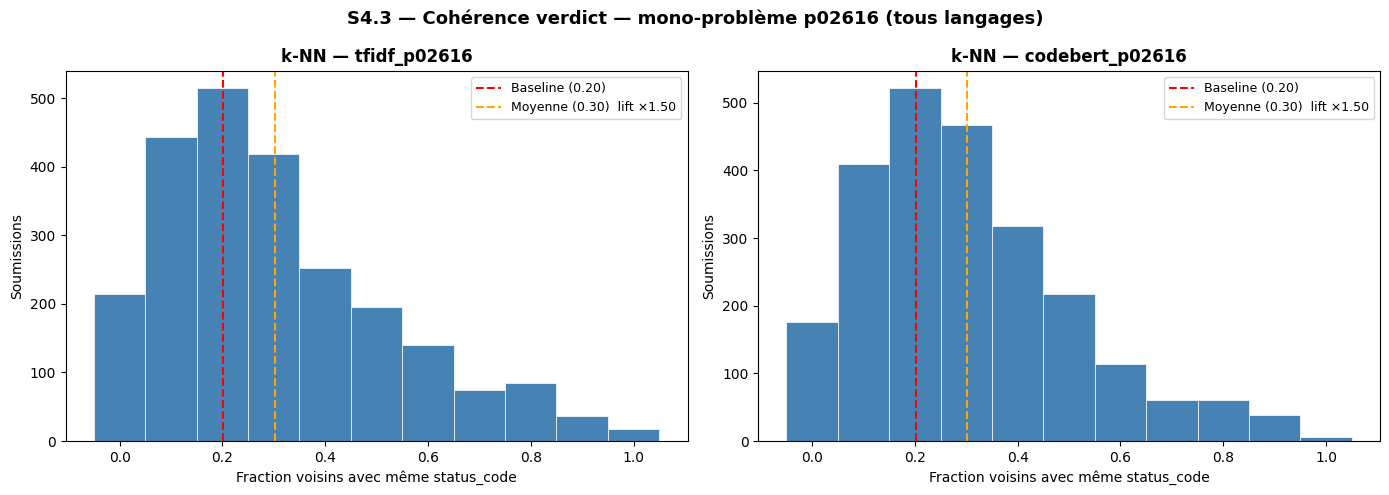

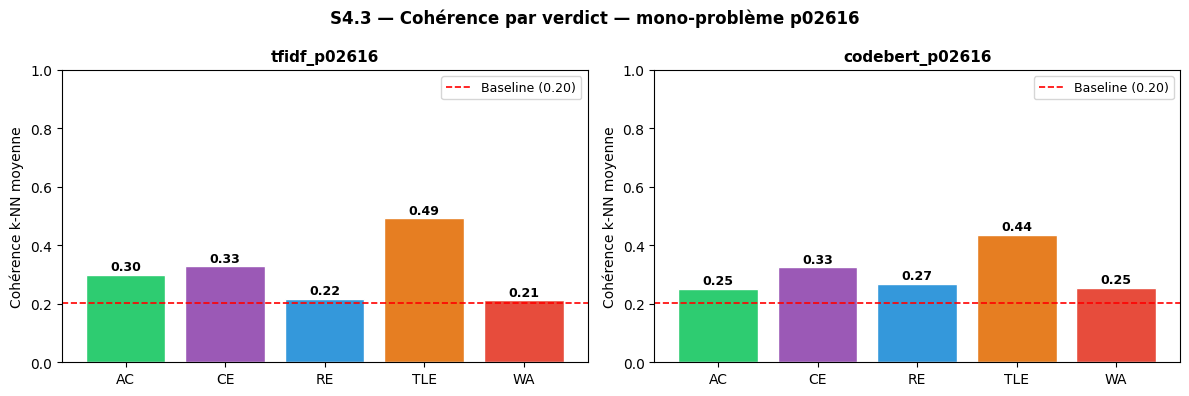

In [16]:
from sklearn.neighbors import NearestNeighbors

K = 10
knn_pb = {}

for m in METHODS_PB:
    if m not in embeddings_pb:
        continue
    emb  = embeddings_pb[m]
    meta = df_meta_pb[m]

    print(f"\nk-NN — {m} (k={K})...")
    nbrs = NearestNeighbors(n_neighbors=K + 1, metric='cosine', algorithm='brute', n_jobs=-1)
    nbrs.fit(emb)
    _, indices = nbrs.kneighbors(emb)

    statuses_arr  = meta['status_code'].to_numpy()
    consistencies = [
        np.sum(statuses_arr[indices[i, 1:]] == statuses_arr[i]) / K
        for i in range(len(statuses_arr))
    ]

    df_meta_pb[m] = meta.with_columns(pl.Series('knn_consistency', consistencies))

    mean_c = float(np.mean(consistencies))
    vc = meta['status_code'].value_counts()
    class_probs   = vc['count'].to_numpy() / len(meta)
    rand_baseline = float(np.sum(class_probs ** 2))

    knn_pb[m] = {'consistencies': consistencies, 'mean_c': mean_c,
                 'rand_baseline': rand_baseline, 'lift': mean_c / rand_baseline}
    print(f"  Cohérence : {mean_c:.3f}  |  baseline : {rand_baseline:.3f}  |  lift ×{mean_c / rand_baseline:.2f}")

# Histogramme k-NN + cohérence par verdict
loaded_pb = [m for m in METHODS_PB if m in knn_pb]
fig, axes = plt.subplots(1, len(loaded_pb), figsize=(7 * len(loaded_pb), 5))
if len(loaded_pb) == 1:
    axes = [axes]

for ax, m in zip(axes, loaded_pb):
    r = knn_pb[m]
    ax.hist(r['consistencies'], bins=K + 1, range=(-0.05, 1.05),
            color='steelblue', edgecolor='white', linewidth=0.5)
    ax.axvline(r['rand_baseline'], color='red',    linestyle='--', linewidth=1.5,
               label=f"Baseline ({r['rand_baseline']:.2f})")
    ax.axvline(r['mean_c'],        color='orange', linestyle='--', linewidth=1.5,
               label=f"Moyenne ({r['mean_c']:.2f})  lift ×{r['lift']:.2f}")
    ax.set_xlabel('Fraction voisins avec même status_code')
    ax.set_ylabel('Soumissions')
    ax.set_title(f'k-NN — {m}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle(f'S4.3 — Cohérence verdict — mono-problème {PROBLEM_ID} (tous langages)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Cohérence moyenne par status_code
fig, axes = plt.subplots(1, len(loaded_pb), figsize=(6 * len(loaded_pb), 4))
if len(loaded_pb) == 1:
    axes = [axes]

for ax, m in zip(axes, loaded_pb):
    meta = df_meta_pb[m]
    means = (meta.group_by('status_code')
             .agg(pl.col('knn_consistency').mean().alias('mean_c'))
             .sort('status_code'))
    colors = [STATUS_COLORS.get(s, '#888') for s in means['status_code'].to_list()]
    bars = ax.bar(means['status_code'].to_list(), means['mean_c'].to_list(),
                  color=colors, edgecolor='white')
    ax.axhline(knn_pb[m]['rand_baseline'], color='red', linestyle='--',
               linewidth=1.2, label=f"Baseline ({knn_pb[m]['rand_baseline']:.2f})")
    for bar, val in zip(bars, means['mean_c'].to_list()):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Cohérence k-NN moyenne')
    ax.set_title(f'{m}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle(f'S4.3 — Cohérence par verdict — mono-problème {PROBLEM_ID}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

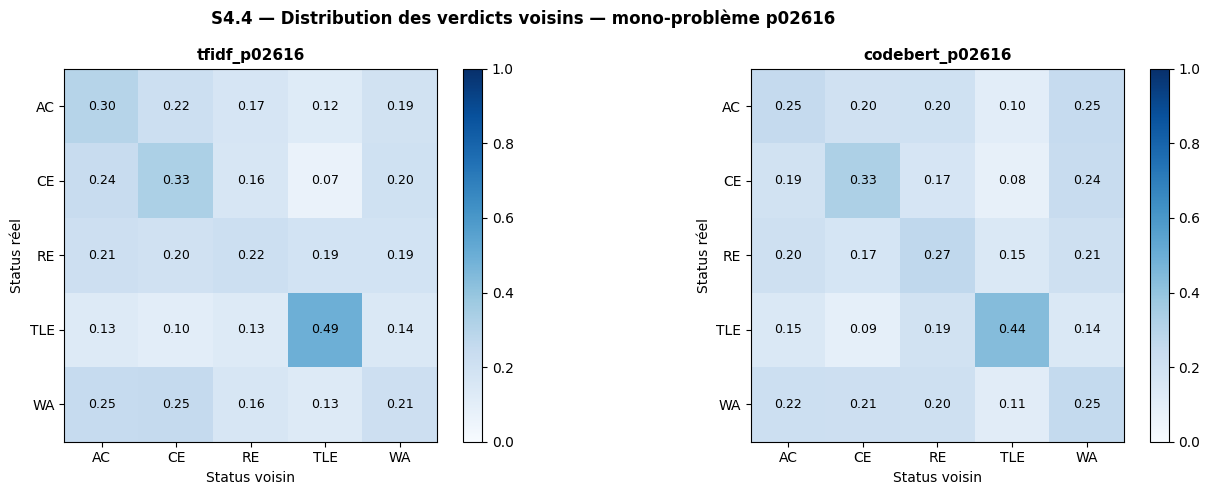

In [17]:
from sklearn.neighbors import NearestNeighbors as _NNpb

# Heatmap : pour chaque status réel, distribution des statuts des 10 plus proches voisins
loaded_pb = [m for m in METHODS_PB if m in embeddings_pb]
fig, axes = plt.subplots(1, len(loaded_pb), figsize=(7 * len(loaded_pb), 5))
if len(loaded_pb) == 1:
    axes = [axes]

for ax, m in zip(axes, loaded_pb):
    emb  = embeddings_pb[m]
    meta = df_meta_pb[m]

    nbrs = _NNpb(n_neighbors=11, metric='cosine', algorithm='brute', n_jobs=-1)
    nbrs.fit(emb)
    _, indices = nbrs.kneighbors(emb)

    statuses_arr = meta['status_code'].to_numpy()
    labels       = sorted(set(statuses_arr))
    label_idx    = {s: i for i, s in enumerate(labels)}
    n_labels     = len(labels)

    matrix = np.zeros((n_labels, n_labels), dtype=float)
    for i, true_s in enumerate(statuses_arr):
        for j in indices[i, 1:]:
            matrix[label_idx[true_s], label_idx[statuses_arr[j]]] += 1

    row_sums = matrix.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    matrix /= row_sums

    im = ax.imshow(matrix, vmin=0, vmax=1, cmap='Blues')
    ax.set_xticks(range(n_labels)); ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticks(range(n_labels)); ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('Status voisin')
    ax.set_ylabel('Status réel')
    ax.set_title(f'{m}', fontsize=11, fontweight='bold')
    for r in range(n_labels):
        for c in range(n_labels):
            ax.text(c, r, f'{matrix[r, c]:.2f}', ha='center', va='center',
                    fontsize=9, color='white' if matrix[r, c] > 0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f'S4.4 — Distribution des verdicts voisins — mono-problème {PROBLEM_ID}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## S5 — Analyse contrôlée : un problème × un langage — C++ vs Python
### S5 — Fully Controlled Analysis: One Problem × One Language — C++ vs Python

Dernier étage de l'entonnoir : problème **et** langage fixés — la variance résiduelle est le seul endroit où le verdict peut vivre. L'analyse est menée en parallèle sur deux langages aux statuts opposés vis-à-vis de CodeBERT :

- **C++** — absent du corpus de pré-entraînement de CodeBERT (hors distribution) ;
- **Python** — langage le mieux représenté de ce pré-entraînement (en distribution).

**Protocole — diff-in-diff.** Les pools C++ et Python d'un même problème ne sont pas directement comparables (populations d'utilisateurs et diversité intrinsèque différentes). On ne compare donc jamais CodeBERT-C++ à CodeBERT-Python en absolu, mais le **gain de CodeBERT sur TF-IDF au sein de chaque langage** : Δ = cohérence(CodeBERT) − cohérence(TF-IDF). TF-IDF subit la même hétérogénéité de pool — le différentiel neutralise l'effet de population.

**Lecture** : Δ_python ≫ Δ_cpp ⇒ le déficit C++ de CodeBERT est réel et mesurable ici. Δ ≈ 0 partout ⇒ CodeBERT n'apporte rien au-delà du lexical sur ce corpus, quel que soit le langage.

```bash
python src/embedding.py tfidf cpu "C++" p02616
python src/embedding.py codebert mps "C++" p02616
python src/embedding.py tfidf cpu "Python" p02616
python src/embedding.py codebert mps "Python" p02616
```

---

Final funnel stage: problem **and** language fixed — residual variance is the only place the verdict can live. The analysis runs in parallel on two languages with opposite status w.r.t. CodeBERT: **C++** (absent from its pre-training corpus, out of distribution) and **Python** (its best-represented language, in distribution).

**Protocol — diff-in-diff.** The C++ and Python pools of a given problem are not directly comparable (different user populations, different intrinsic diversity). We therefore never compare CodeBERT-C++ to CodeBERT-Python in absolute terms, but the **gain of CodeBERT over TF-IDF within each language**: Δ = consistency(CodeBERT) − consistency(TF-IDF). TF-IDF suffers the same pool heterogeneity — the differential neutralizes the population effect.

**Reading**: Δ_python ≫ Δ_cpp ⇒ CodeBERT's C++ deficit is real and measurable here. Δ ≈ 0 everywhere ⇒ CodeBERT adds nothing beyond lexical signal on this corpus, regardless of language.

tfidf_cpp_p02616               : n=2,036 | cohérence 0.272 | baseline 0.229 | lift ×1.19
codebert_cpp_p02616            : n=2,036 | cohérence 0.275 | baseline 0.229 | lift ×1.20
tfidf_python_p02616            : n=1,753 | cohérence 0.351 | baseline 0.265 | lift ×1.33
codebert_python_p02616         : n=1,753 | cohérence 0.342 | baseline 0.265 | lift ×1.29


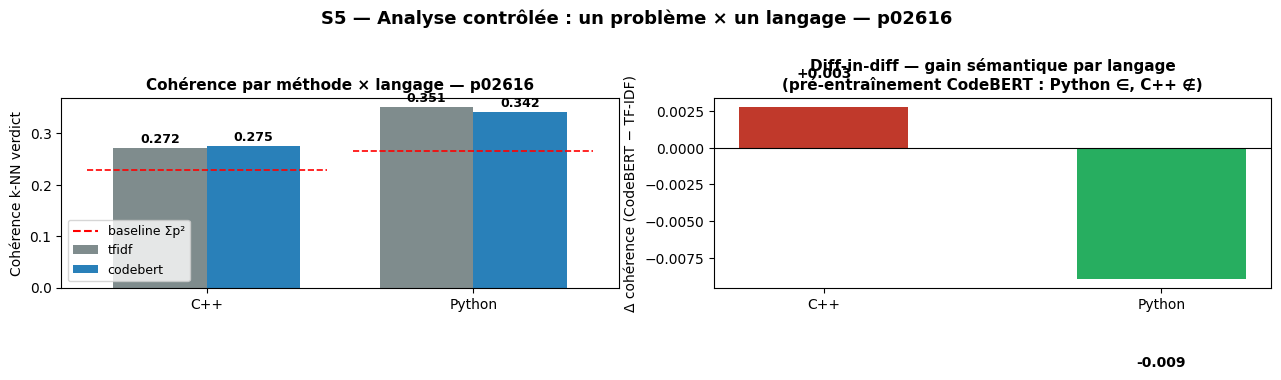

In [20]:
# S5 — cohérence k-NN verdict pour les 4 corpus (méthode × langage), puis diff-in-diff
from sklearn.neighbors import NearestNeighbors

LANGS_S5 = {'cpp': 'C++', 'python': 'Python'}
K = 10

s5_results = {}   # (method_base, lang_tag) -> métriques
for lang_tag, lang_name in LANGS_S5.items():
    for base in ['tfidf', 'codebert']:
        tag = f"{base}_{lang_tag}_{PROBLEM_ID}"
        emb_path  = EMBEDDINGS_DIR / f"embeddings_{tag}.npy"
        meta_path = EMBEDDINGS_DIR / f"metadata_{tag}.csv"
        if not emb_path.exists():
            device = 'cpu' if base == 'tfidf' else 'mps'
            print(f"[MANQUANT] {tag} — lancer : python src/embedding.py {base} {device} \"{lang_name}\" {PROBLEM_ID}")
            continue
        emb  = np.load(emb_path)
        meta = pl.read_csv(meta_path)

        nbrs = NearestNeighbors(n_neighbors=K + 1, metric='cosine', algorithm='brute', n_jobs=-1)
        nbrs.fit(emb)
        _, idx = nbrs.kneighbors(emb)
        statuses = meta['status_code'].to_numpy()
        cons = float(np.mean([
            np.sum(statuses[idx[i, 1:]] == statuses[i]) / K for i in range(len(statuses))
        ]))
        probs    = meta['status_code'].value_counts()['count'].to_numpy() / len(meta)
        baseline = float(np.sum(probs ** 2))
        s5_results[(base, lang_tag)] = {'consistency': cons, 'baseline': baseline,
                                        'lift': cons / baseline, 'n': meta.height}
        print(f"{tag:30s} : n={meta.height:,} | cohérence {cons:.3f} | baseline {baseline:.3f} | lift ×{cons/baseline:.2f}")

# --- Figure : cohérences (gauche) et diff-in-diff Δ = CodeBERT − TF-IDF (droite) ---
if s5_results:
    lang_labels = list(LANGS_S5.values())
    x, width = np.arange(len(LANGS_S5)), 0.35

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    for off, base, color in [(-width/2, 'tfidf', '#7f8c8d'), (width/2, 'codebert', '#2980b9')]:
        vals = [s5_results.get((base, t), {}).get('consistency', np.nan) for t in LANGS_S5]
        bars = ax1.bar(x + off, vals, width, label=base, color=color)
        for b, v in zip(bars, vals):
            if not np.isnan(v):
                ax1.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.3f}',
                         ha='center', fontsize=9, fontweight='bold')
    for xi, t in zip(x, LANGS_S5):
        ref = s5_results.get(('tfidf', t)) or s5_results.get(('codebert', t))
        if ref:
            ax1.hlines(ref['baseline'], xi - 0.45, xi + 0.45,
                       color='red', linestyle='--', linewidth=1.2)
    ax1.plot([], [], color='red', linestyle='--', label='baseline Σp²')
    ax1.set_xticks(x); ax1.set_xticklabels(lang_labels)
    ax1.set_ylabel('Cohérence k-NN verdict')
    ax1.set_title(f'Cohérence par méthode × langage — {PROBLEM_ID}',
                  fontsize=11, fontweight='bold')
    ax1.legend(fontsize=9)

    deltas = []
    for t in LANGS_S5:
        if ('codebert', t) in s5_results and ('tfidf', t) in s5_results:
            deltas.append(s5_results[('codebert', t)]['consistency']
                          - s5_results[('tfidf', t)]['consistency'])
        else:
            deltas.append(np.nan)
    bars = ax2.bar(lang_labels, deltas, color=['#c0392b', '#27ae60'], width=0.5)
    ax2.axhline(0, color='black', linewidth=0.8)
    for b, v in zip(bars, deltas):
        if not np.isnan(v):
            ax2.text(b.get_x() + b.get_width()/2, v + (0.002 if v >= 0 else -0.006),
                     f'{v:+.3f}', ha='center', fontsize=10, fontweight='bold')
    ax2.set_ylabel('Δ cohérence (CodeBERT − TF-IDF)')
    ax2.set_title('Diff-in-diff — gain sémantique par langage\n(pré-entraînement CodeBERT : Python ∈, C++ ∉)',
                  fontsize=11, fontweight='bold')

    plt.suptitle(f'S5 — Analyse contrôlée : un problème × un langage — {PROBLEM_ID}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Aucun corpus S5 disponible — générer les embeddings avec les commandes ci-dessus.")

---
## S6 — Synthèse & décision
### S6 — Synthesis & Decision

Grille de lecture de l'entonnoir — à compléter avec les valeurs mesurées après exécution complète :

| Étape | Corpus | Lift verdict (TF-IDF / CodeBERT) | Enseignement |
|---|---|---|---|
| S2 | global | … / … | hiérarchie des signaux ; difficulté = artefact de H2 ? |
| S3 | C++ seul, tous problèmes | … / … | gain apporté par le contrôle du langage |
| S4 | 1 problème, tous langages | … / … | ponts inter-langages : sémantiques ou non (S4.2) |
| S5 | 1 problème × 1 langage | … / … | signal net final ; Δ C++ vs Python |

**Critères de décision pour la suite de RQ2 :**

- **Lift verdict S5 ≈ 1 pour les deux méthodes** → l'embedding gelé ne suffit pas ; pistes : fine-tuning supervisé, encodeurs de code récents, ou features dédiées (AST, métriques de complexité).
- **Δ_python ≫ Δ_cpp** → le déficit C++ de CodeBERT est confirmé ; privilégier un corpus Python pour la suite, ou un encodeur couvrant C++ (GraphCodeBERT, CodeT5+, StarCoder…).
- **Accord verdict inter-langages (S4.2) > baseline** → l'espace porte une part de logique transférable au-delà de la syntaxe : argument direct pour poursuivre l'analyse sémantique au niveau « approche algorithmique ».

---

Funnel reading grid — to be filled with measured values after a full run: S2 establishes the signal hierarchy (is difficulty an H2 artifact?), S3 the language-control gain, S4 whether cross-language bridges are semantic (S4.2), S5 the final controlled signal and the C++ vs Python Δ.

**Decision criteria for the rest of RQ2:** if the S5 verdict lift stays ≈ 1 for both methods → frozen embeddings are insufficient (next: supervised fine-tuning, newer code encoders, or dedicated features — AST, complexity metrics). If Δ_python ≫ Δ_cpp → CodeBERT's C++ deficit is confirmed; favor a Python corpus going forward, or an encoder covering C++ (GraphCodeBERT, CodeT5+, StarCoder…). If cross-language verdict agreement (S4.2) beats the baseline → the space carries logic transferable beyond syntax: a direct case for algorithm-level semantic analysis.